In [1]:
#  core
import pandas as pd
import numpy as np
import joblib
# visualization
import seaborn as sns
import matplotlib.pyplot as plt
# preprocessing
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
# modelling
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
# evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

Data Analysis Pepeline:
1. Data Exploration
2. Data Cleaning
3. Feature Engineering
4. EDA (Visualisation)
5. Data Preprocessing (Scaling & Encoding)
6. Feature Selection
7. Modeling
8. Model Evaluation & Optimization
9. Deployment & Interpretation

# **STEP 1: Data Exploration**

## **Column Descriptions**

> Dataset Name: Kaggle Housing Prices Prediction – Basic to Advanced Regression Techniques

> Objective: Predict the final sale price of residential homes in Ames, Iowa.
 
> Problem Type: Regression (continuous target variable: SalePrice)

> Data Shape:
- Training Set: (1460 rows, 81 columns) → Contains features and the SalePrice label.
- Test Set: (1459 rows, 80 columns) → Same features as training data, but without the SalePrice label.


> When converted into a Pandas DataFrame:

### SalePrice
- Final sale price (target variable) (float).

### MSSubClass
- Type of dwelling involved in sale (integer; treat as categorical).
- Possible values:
  - 20: 1-Story 1946 & Newer All Styles
  - 30: 1-Story 1945 & Older
  - 40: 1-Story with Finished Attic
  - 45: 1.5-Story Unfinished
  - 50: 1.5-Story Finished
  - 60: 2-Story 1946 & Newer
  - 70: 2-Story 1945 & Older
  - 75: 2.5-Story All Ages
  - 80: Split or Multi-Level
  - 85: Split Foyer
  - 90: Duplex
  - 120: 1-Story PUD 1946 & Newer
  - 150: 1.5-Story PUD
  - 160: 2-Story PUD 1946 & Newer
  - 180: PUD Multilevel
  - 190: 2-Family Conversion

### MSZoning
- General zoning classification (string).
- Possible values:
  - A: Agriculture
  - C: Commercial
  - FV: Floating Village Residential
  - I: Industrial
  - RH: Residential High Density
  - RL: Residential Low Density
  - RP: Residential Low Density Park
  - RM: Residential Medium Density

### LotFrontage
- Linear feet of street connected to property (float).

### LotArea
- Lot size in square feet (integer).

### Street
- Type of road access to property (string).
- Possible values:
  - Grvl: Gravel
  - Pave: Paved

### Alley
- Type of alley access (string).
- Possible values:
  - Grvl: Gravel
  - Pave: Paved
  - NA: No alley access

### LotShape
- General shape of property (string).
- Possible values:
  - Reg: Regular
  - IR1: Slightly irregular
  - IR2: Moderately irregular
  - IR3: Irregular

### LandContour
- Flatness of the property (string).
- Possible values:
  - Lvl: Level
  - Bnk: Banked
  - HLS: Hillside
  - Low: Depression

### Utilities
- Type of utilities available (string).
- Possible values:
  - AllPub: All public utilities
  - NoSewr: Electricity, Gas, Water (Septic)
  - NoSeWa: Electricity and Gas only
  - ELO: Electricity only

### LotConfig
- Lot configuration (string).
- Possible values:
  - Inside: Inside lot
  - Corner: Corner lot
  - CulDSac: Cul-de-sac
  - FR2: Frontage on 2 sides
  - FR3: Frontage on 3 sides

### LandSlope
- Slope of property (string).
- Possible values:
  - Gtl: Gentle slope
  - Mod: Moderate slope
  - Sev: Severe slope

### Neighborhood
- Physical locations within Ames city limits (string).
- Possible values (examples):
  - Blmngtn, Blueste, BrDale, BrkSide, ClearCr, CollgCr, Crawfor, Edwards, Gilbert, IDOTRR, MeadowV, Mitchel, Names, NoRidge, NPkVill, NridgHt, NWAmes, OldTown, SWISU, Sawyer, SawyerW, Somerst, StoneBr, Timber, Veenker

### Condition1
- Proximity to main road or railroad (string).
- Possible values:
  - Artery: Adjacent to arterial street
  - Feedr: Adjacent to feeder street
  - Norm: Normal
  - RRNn: Within 200' of North-South Railroad
  - RRAn: Adjacent to North-South Railroad
  - PosN: Near park/greenbelt
  - PosA: Adjacent to park/greenbelt
  - RRNe: Within 200' of East-West Railroad
  - RRAe: Adjacent to East-West Railroad

### Condition2
- Proximity to various conditions (if more than one is present) (string).
- Possible values:
  - Same as Condition1 (Artery, Feedr, Norm, RRNn, RRAn, PosN, PosA, RRNe, RRAe)

### BldgType
- Type of dwelling (string).
- Possible values:
  - 1Fam: Single-family Detached
  - 2FmCon: Two-family Conversion
  - Duplx: Duplex
  - TwnhsE: Townhouse End Unit
  - TwnhsI: Townhouse Inside Unit

### HouseStyle
- Style of dwelling (string).
- Possible values:
  - 1Story: One story
  - 1.5Fin: 1.5 story (finished)
  - 1.5Unf: 1.5 story (unfinished)
  - 2Story: Two story
  - 2.5Fin: 2.5 story (finished)
  - 2.5Unf: 2.5 story (unfinished)
  - SFoyer: Split Foyer
  - SLvl: Split Level

### OverallQual
- Overall material and finish quality (ordinal integer 1–10).
- Possible values:
  - 10: Very Excellent
  - 9: Excellent
  - 8: Very Good
  - 7: Good
  - 6: Above Average
  - 5: Average
  - 4: Below Average
  - 3: Fair
  - 2: Poor
  - 1: Very Poor

### OverallCond
- Overall condition rating (ordinal integer 1–10).
- Possible values:
  - Same as OverallQual (10 = Very Excellent, 1 = Very Poor)

### YearBuilt
- Original construction date (integer).

### YearRemodAdd
- Remodel date (integer; same as construction date if no remodeling).

### RoofStyle
- Type of roof (string).
- Possible values:
  - Flat
  - Gable
  - Gambrel
  - Hip
  - Mansard
  - Shed

### RoofMatl
- Roof material (string).
- Possible values:
  - ClyTile: Clay or Tile
  - CompShg: Composite Shingle
  - Membran: Membrane
  - Metal: Metal
  - Roll: Roll Roofing
  - Tar&Grv: Gravel and Tar
  - WdShake: Wood Shakes
  - WdShngl: Wood Shingles

### Exterior1st
- Primary exterior material (string).
- Possible values:
  - AsbShng, AsphShn, BrkComm, BrkFace, CBlock, CemntBd, HdBoard, ImStucc, MetalSd, Other, Plywood, PreCast, Stone, Stucco, VinylSd, Wd Sdng, WdShing

### Exterior2nd
- Secondary exterior material (string).
- Same options as Exterior1st.

### MasVnrType
- Masonry veneer type (string).
- Possible values:
  - BrkCmn: Brick Common
  - BrkFace: Brick Face
  - CBlock: Cinder Block
  - None: None
  - Stone: Stone

### MasVnrArea
- Masonry veneer area in square feet (float).

### ExterQual
- Exterior material quality (ordinal).
- Possible values:
  - Ex: Excellent
  - Gd: Good
  - TA: Typical/Average
  - Fa: Fair
  - Po: Poor

### ExterCond
- Exterior material condition (ordinal).
- Possible values:
  - Ex: Excellent
  - Gd: Good
  - TA: Typical/Average
  - Fa: Fair
  - Po: Poor

### Foundation
- Type of foundation (string).
- Possible values:
  - BrkTil: Brick & Tile
  - CBlock: Cinder Block
  - PConc: Poured Concrete
  - Slab: Slab
  - Stone: Stone
  - Wood: Wood

### BsmtQual
- Height of basement (ordinal).
- Possible values:
  - Ex: Excellent (100+ inches)
  - Gd: Good (90–99 inches)
  - TA: Typical (80–89 inches)
  - Fa: Fair (70–79 inches)
  - Po: Poor (<70 inches)
  - NA: No Basement

### BsmtCond
- General basement condition (ordinal).
- Possible values:
  - Ex: Excellent
  - Gd: Good
  - TA: Typical
  - Fa: Fair
  - Po: Poor
  - NA: No Basement

### BsmtExposure
- Walkout or garden level basement walls exposure (string).
- Possible values:
  - Gd: Good Exposure
  - Av: Average Exposure
  - Mn: Minimum Exposure
  - No: No Exposure
  - NA: No Basement

### BsmtFinType1
- Quality of basement finished area 1 (ordinal).
- Possible values:
  - GLQ: Good Living Quarters
  - ALQ: Average Living Quarters
  - BLQ: Below Average Living Quarters
  - Rec: Average Rec Room
  - LwQ: Low Quality
  - Unf: Unfinished
  - NA: No Basement

### BsmtFinSF1
- Area of type 1 basement finished square feet (float).

### BsmtFinType2
- Quality of basement finished area 2 (ordinal).
- Same options as BsmtFinType1.

### BsmtFinSF2
- Area of type 2 basement finished square feet (float).

### BsmtUnfSF
- Unfinished basement area in square feet (float).

### TotalBsmtSF
- Total basement area in square feet (float).

### Heating
- Type of heating (string).
- Possible values:
  - Floor: Floor Furnace
  - GasA: Gas forced warm air furnace
  - GasW: Gas hot water or steam heat
  - Grav: Gravity furnace
  - OthW: Hot water or steam heat other than gas
  - Wall: Wall furnace

### HeatingQC
- Heating quality and condition (ordinal).
- Possible values:
  - Ex: Excellent
  - Gd: Good
  - TA: Typical
  - Fa: Fair
  - Po: Poor

### CentralAir
- Central air conditioning (string).
- Possible values:
  - Y: Yes
  - N: No

### Electrical
- Electrical system type (string).
- Possible values:
  - SBrkr: Standard Circuit Breakers & Romex
  - FuseA: Fuse Box over 60 AMP and all Romex wiring
  - FuseF: 60 AMP Fuse Box and mostly Romex
  - FuseP: 60 AMP Fuse Box and mostly knob & tube wiring
  - Mix: Mixed

### 1stFlrSF
- First floor square feet (integer).

### 2ndFlrSF
- Second floor square feet (integer).

### LowQualFinSF
- Low quality finished square feet (integer).

### GrLivArea
- Above grade (ground level) living area square feet (integer).

### BsmtFullBath
- Number of basement full bathrooms (integer).

### BsmtHalfBath
- Number of basement half bathrooms (integer).

### FullBath
- Number of full bathrooms above grade (integer).

### HalfBath
- Number of half bathrooms above grade (integer).

### BedroomAbvGr
- Number of bedrooms above grade (integer).

### KitchenAbvGr
- Number of kitchens above grade (integer).

### KitchenQual
- Kitchen quality (ordinal).
- Possible values:
  - Ex: Excellent
  - Gd: Good
  - TA: Typical/Average
  - Fa: Fair
  - Po: Poor

### TotRmsAbvGrd
- Total rooms above grade (excluding bathrooms) (integer).

### Functional
- Home functionality rating (string).
- Possible values:
  - Typ: Typical Functionality
  - Min1: Minor Deductions 1
  - Min2: Minor Deductions 2
  - Mod: Moderate Deductions
  - Maj1: Major Deductions 1
  - Maj2: Major Deductions 2
  - Sev: Severely Damaged
  - Sal: Salvage only

### Fireplaces
- Number of fireplaces (integer).

### FireplaceQu
- Fireplace quality (ordinal).
- Possible values:
  - Ex: Excellent - Exceptional Masonry Fireplace
  - Gd: Good - Masonry Fireplace in main level
  - TA: Average - Prefabricated or Masonry Fireplace
  - Fa: Fair - Prefabricated Fireplace in basement
  - Po: Poor - Ben Franklin Stove
  - NA: No Fireplace

### GarageType
- Garage location (string).
- Possible values:
  - 2Types: More than one type of garage
  - Attchd: Attached to home
  - Basment: Basement Garage
  - BuiltIn: Built-In Garage
  - CarPort: Car Port
  - Detchd: Detached from home
  - NA: No Garage

### GarageYrBlt
- Year garage was built (integer, may have missing values).

### GarageFinish
- Interior finish of the garage (string).
- Possible values:
  - Fin: Finished
  - RFn: Rough Finished
  - Unf: Unfinished
  - NA: No Garage

### GarageCars
- Size of garage in car capacity (integer).

### GarageArea
- Size of garage in square feet (integer).

### GarageQual
- Garage quality (ordinal).
- Possible values:
  - Ex: Excellent
  - Gd: Good
  - TA: Typical/Average
  - Fa: Fair
  - Po: Poor
  - NA: No Garage

### GarageCond
- Garage condition (ordinal).
- Possible values:
  - Ex: Excellent
  - Gd: Good
  - TA: Typical/Average
  - Fa: Fair
  - Po: Poor
  - NA: No Garage

### PavedDrive
- Paved driveway (string).
- Possible values:
  - Y: Paved
  - P: Partial pavement
  - N: Dirt/Gravel

### WoodDeckSF
- Wood deck area in square feet (integer).

### OpenPorchSF
- Open porch area in square feet (integer).

### EnclosedPorch
- Enclosed porch area in square feet (integer).

### 3SsnPorch
- Three season porch area in square feet (integer).

### ScreenPorch
- Screened porch area in square feet (integer).

### PoolArea
- Pool area in square feet (integer).

### PoolQC
- Pool quality (ordinal).
- Possible values:
  - Ex: Excellent
  - Gd: Good
  - TA: Average/Typical
  - Fa: Fair
  - NA: No Pool

### Fence
- Fence quality (string).
- Possible values:
  - GdPrv: Good Privacy
  - MnPrv: Minimum Privacy
  - GdWo: Good Wood
  - MnWw: Minimum Wood/Wire
  - NA: No Fence

### MiscFeature
- Miscellaneous feature not covered in other categories (string).
- Possible values:
  - Elev: Elevator
  - Gar2: 2nd Garage
  - Othr: Other
  - Shed: Shed
  - TenC: Tennis Court
  - NA: None

### MiscVal
- Value of miscellaneous feature in dollars (integer).

### MoSold
- Month sold (integer: 1–12).

### YrSold
- Year sold (integer, e.g., 2006–2010).

### SaleType
- Type of sale (string).
- Possible values:
  - WD: Warranty Deed - Conventional
  - CWD: Warranty Deed - Cash
  - VWD: Warranty Deed - VA Loan
  - New: Home just constructed and sold
  - COD: Court Officer Deed/Estate
  - Con: Contract 15% Down payment
  - ConLw: Contract Low Down payment
  - ConLI: Contract Low Interest
  - ConLD: Contract Low Down
  - Oth: Other

### SaleCondition
- Condition of sale (string).
- Possible values:
  - Normal: Normal Sale
  - Abnorml: Abnormal Sale - trade, foreclosure, short sale
  - AdjLand: Adjoining Land Purchase
  - Alloca: Allocation - two linked properties
  - Family: Sale between family members
  - Partial: Home not completed when last assessed

## **Descriptive Statistics**

> Descriptive statistics summarize and describe the key features of a dataset.

In [2]:
# load the dataset
train = pd.read_csv('C:/Users/ARZ/Desktop/train.csv')
test = pd.read_csv('C:/Users/ARZ/Desktop/test.csv')

In [3]:
def dataset_snapshot(df):
    head = df.head(3)
    tail = df.tail(3)
    sample = df.sample(3)
    return pd.concat([head, tail, sample])

dataset_snapshot(train)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500
850,851,120,RM,36.0,4435,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2007,WD,Normal,131500
806,807,80,RL,75.0,9750,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2006,WD,Normal,135500
772,773,80,RL,94.0,7819,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Abnorml,107000


In [4]:
def quick_overview(df):
    return pd.DataFrame({
        "dtype": df.dtypes,
        "nunique": df.nunique(),
        "missing": df.isnull().sum()
    }).reset_index().rename(columns={"index": "column"})
quick_overview(train)

,column,dtype,nunique,missing
0,Id,int64,1460,0
1,MSSubClass,int64,15,0
2,MSZoning,object,5,0
3,LotFrontage,float64,110,259
4,LotArea,int64,1073,0
...,...,...,...,...
76,MoSold,int64,12,0
77,YrSold,int64,5,0
78,SaleType,object,9,0
79,SaleCondition,object,6,0


In [5]:
def check_df(df, target=None, head=3):
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 500)

    print("#################### SHAPE ########################")
    print(f"🔹 Rows: {df.shape[0]} | 🔹 Columns: {df.shape[1]}\n")
    
    print("#################### INFO #########################")
    print(df.info(), "\n")
 
    print("################## DESCRIPTIVE STATS (numerical) ##################")
    display(df.describe().T.style.background_gradient(cmap='PuBu'))
    
    print("################## DESCRIPTIVE STATS (categorical) ##################")
    display(df.describe(include='object').T.style.background_gradient(cmap='Oranges'))
    
    print("################## DUPLICATES ##################")
    print(f"🔁 Duplicate Rows: {df.duplicated().sum()}\n")

    if target and target in df.columns:
        print("############ TARGET DISTRIBUTION ############")
        print(df[target].value_counts(), "\n")

check_df(train, target= 'SalesPrice')

#################### SHAPE ########################
🔹 Rows: 1460 | 🔹 Columns: 81

#################### INFO #########################
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgTy

,count,mean,std,min,25%,50%,75%,max
Id,1460.000000,730.500000,421.610009,1.000000,365.750000,730.500000,1095.250000,1460.000000
MSSubClass,1460.000000,56.897260,42.300571,20.000000,20.000000,50.000000,70.000000,190.000000
LotFrontage,1201.000000,70.049958,24.284752,21.000000,59.000000,69.000000,80.000000,313.000000
LotArea,1460.000000,10516.828082,9981.264932,1300.000000,7553.500000,9478.500000,11601.500000,215245.000000
OverallQual,1460.000000,6.099315,1.382997,1.000000,5.000000,6.000000,7.000000,10.000000
OverallCond,1460.000000,5.575342,1.112799,1.000000,5.000000,5.000000,6.000000,9.000000
YearBuilt,1460.000000,1971.267808,30.202904,1872.000000,1954.000000,1973.000000,2000.000000,2010.000000
YearRemodAdd,1460.000000,1984.865753,20.645407,1950.000000,1967.000000,1994.000000,2004.000000,2010.000000
MasVnrArea,1452.000000,103.685262,181.066207,0.000000,0.000000,0.000000,166.000000,1600.000000
BsmtFinSF1,1460.000000,443.639726,456.098091,0.000000,0.000000,383.500000,712.250000,5644.000000


################## DESCRIPTIVE STATS (categorical) ##################


,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


################## DUPLICATES ##################
🔁 Duplicate Rows: 0



# **STEP 2: Data Cleaning**

### **1️⃣Handle missing values**

In [6]:
missing_values = train.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [7]:
# fill categorical columns with 'None'
cat_cols = ['PoolQC', 'Fence', 'MiscFeature', 'Alley', 'FireplaceQu', 
            'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
            'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
            'BsmtFinType2', 'MasVnrType']

for df in [train, test]:
    for col in cat_cols:
        df[col] = df[col].fillna('None')

In [8]:
# fill numerical columns with 0
num_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea']

for df in [train,test]:
    for col in num_cols:
        df[col] = df[col].fillna(0)

In [9]:
# fill LotFrontage by median of grouped Neighborhood 
for df in [train,test]:
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )

In [10]:
# fill Electrical with the mode
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

In [11]:
test_cols = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']
for col in test_cols:
    test[col] = test[col].fillna(0)

In [12]:
test_mode = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']
for col in test_mode:
    test[col] = test[col].fillna(test[col].mode()[0])

In [13]:
print("🔍 Missing values in TRAIN set:")
print(train.isnull().sum()[train.isnull().sum() > 0])

print("\n🔍 Missing values in TEST set:")
print(test.isnull().sum()[test.isnull().sum() > 0])

🔍 Missing values in TRAIN set:
Series([], dtype: int64)

🔍 Missing values in TEST set:
Series([], dtype: int64)


### **2️⃣ Remove duplicates**

In [14]:
# sanity check for duplicated values 
train.duplicated().sum()
test.duplicated().sum()

0

### **3️⃣ Remove features**

In [15]:
# Id is just an identifier ➔ No impact on SalePrice.
# Utilities is almost always the same ➔ Model will ignore it or get confused by it.

for df in [train, test]:
    df.drop(columns=['Id', 'Utilities'], inplace=True)

### **4️⃣ Fix incorrect/inconsistent data**

> Deals with wrong, inconsistent, or messy values (e.g., typos, inconsistent formats, leading/trailing spaces).

In [16]:
# Remove Leading/Trailing Spaces from Text Columns
for df in [train,test]:
    cat_columns = df.select_dtypes(include=['object']).columns
    df[cat_columns] = df[cat_columns].apply(lambda x: x.str.strip())

In [17]:
def show_unique_categories(df):
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        print(f"{col} ({df[col].nunique()} unique): {df[col].unique()[:5]}{'...' if df[col].nunique() > 5 else ''}")

show_unique_categories(train)

# - Inspected unique values manually.
# - No typos, casing issues, or category mismatches detected.

MSZoning (5 unique): ['RL' 'RM' 'C (all)' 'FV' 'RH']
Street (2 unique): ['Pave' 'Grvl']
Alley (3 unique): ['None' 'Grvl' 'Pave']
LotShape (4 unique): ['Reg' 'IR1' 'IR2' 'IR3']
LandContour (4 unique): ['Lvl' 'Bnk' 'Low' 'HLS']
LotConfig (5 unique): ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
LandSlope (3 unique): ['Gtl' 'Mod' 'Sev']
Neighborhood (25 unique): ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel']...
Condition1 (9 unique): ['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe']...
Condition2 (8 unique): ['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN']...
BldgType (5 unique): ['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']
HouseStyle (8 unique): ['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer']...
RoofStyle (6 unique): ['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat']...
RoofMatl (8 unique): ['CompShg' 'WdShngl' 'Metal' 'WdShake' 'Membran']...
Exterior1st (15 unique): ['VinylSd' 'MetalSd' 'Wd Sdng' 'HdBoard' 'BrkFace']...
Exterior2nd (16 unique): ['VinylSd' 'MetalSd' 'Wd Shng' 'HdBoard' 'Plywood']...
MasVnrType (4 u

# **STEP 3: Feature Engineering**
- In this step, we create new meaningful features from existing data.

In [18]:
# TotalBathrooms = FullBath + HalfBath * 0.5 + BsmtFullBath + BsmtHalfBath * 0.5
for df in [train,test]:
    df['TotalBathrooms'] = df['FullBath'] + df['HalfBath'] * 0.5 + df['BsmtFullBath'] + df['BsmtHalfBath'] * 0.5
train['TotalBathrooms'].value_counts()

TotalBathrooms
2.0    456
2.5    295
1.0    228
3.0    186
3.5    144
1.5    129
4.0     13
4.5      7
6.0      1
5.0      1
Name: count, dtype: int64

In [19]:
# HouseAge = YrSold - YearBuilt
for df in [train,test]:
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
train['HouseAge'].value_counts()
# HouseAge = 0 => built and sold in the same year

HouseAge
1      100
0       64
4       41
2       39
3       36
      ... 
115      1
122      1
128      1
114      1
125      1
Name: count, Length: 122, dtype: int64

In [20]:
# TotalSF = Total living space (1stFlrSF + 2ndFlrSF + TotalBsmtSF)	
for df in [train,test]:
    df['TotalSF'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']
train['TotalSF'].value_counts()

TotalSF
1728    22
1788    12
1696    11
1632    10
2184     9
        ..
1557     1
4026     1
2808     1
3608     1
2512     1
Name: count, Length: 963, dtype: int64

In [21]:
# TotalPorchSF = Total porch area (sum of OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch)	
for df in [train,test]:
    df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']
train['TotalPorchSF'].value_counts()

TotalPorchSF
0      458
36      27
40      20
48      19
45      18
      ... 
285      1
366      1
638      1
37       1
316      1
Name: count, Length: 287, dtype: int64

# **STEP 4: EDA**

> EDA helps understand the distribution, relationships, and trends in data before applying machine learning or advanced analysis.

### **1️⃣ Outlier Detection**

In [22]:
train.describe().style.background_gradient(cmap='BrBG')

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,TotalBathrooms,HouseAge,TotalSF,TotalPorchSF
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.199658,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1868.739726,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890,2.210616,36.547945,2567.048630,87.084932
std,42.300571,22.431902,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,453.697295,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883,0.785399,30.250152,821.714421,105.190364
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000,1.000000,0.000000,334.000000,0.000000
25%,20.000000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1958.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000,2.000000,8.000000,2009.500000,0.000000
50%,50.000000,70.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1977.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000,2.000000,35.000000,2474.000000,48.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2001.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000,2.500000,54.000000,3004.000000,136.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000,6.000000,136.000000,11752.000000,1027.000000


In [23]:
numeric_cols = [
    'SalePrice', 'LotFrontage', 'LotArea', 'GrLivArea',
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'TotalSF',
    'GarageArea', 'GarageCars', 'TotalPorchSF',
    'OverallQual', 'OverallCond', 'HouseAge'
]

In [24]:
# IDENTIFYING OUTLIERS using IQR since the data is skewed

Q1 = train[numeric_cols].quantile(0.25)
Q3 = train[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = (
    train[numeric_cols] < lower_bound) | (train[numeric_cols] > upper_bound)

# Display rows where any column has an outlier
outlier_detected = train.loc[outliers_iqr.any(axis=1), numeric_cols]
display(outlier_detected)

,SalePrice,LotFrontage,LotArea,GrLivArea,TotalBsmtSF,1stFlrSF,2ndFlrSF,TotalSF,GarageArea,GarageCars,TotalPorchSF,OverallQual,OverallCond,HouseAge
1,181500,80.0,9600,1262,1262,1262,0,2524,460,2,0,6,8,31
5,143000,85.0,14115,1362,796,796,566,2158,480,2,350,5,5,16
7,200000,80.0,10382,2090,1107,1107,983,3197,484,2,432,7,6,36
11,345000,85.0,11924,2324,1175,1182,1142,3499,736,3,21,9,5,1
14,157000,73.0,10920,1253,1253,1253,0,2506,352,1,389,6,5,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,174000,80.0,8400,1537,1319,1537,0,2856,462,2,36,6,9,46
1437,394617,96.0,12444,1932,1932,1932,0,3864,774,3,370,8,5,0
1446,157900,73.0,26142,1188,1188,1188,0,2376,312,1,39,5,7,48
1449,92000,21.0,1533,630,630,630,0,1260,0,0,0,5,7,36


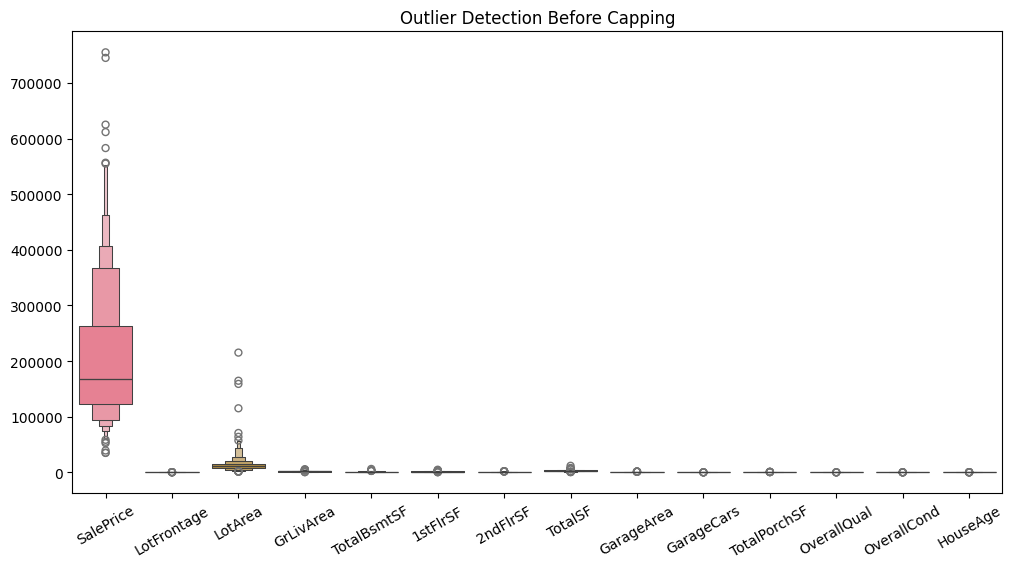

In [25]:
# visualize outliers before capping
plt.figure(figsize=(12, 6))
sns.boxenplot(data=outlier_detected)
plt.xticks(rotation=30)  # Rotates the x-axis labels
plt.title("Outlier Detection Before Capping")
plt.show()

# no further actions needed as all outliers are legit.

### **2️⃣ Numeric Distributions**

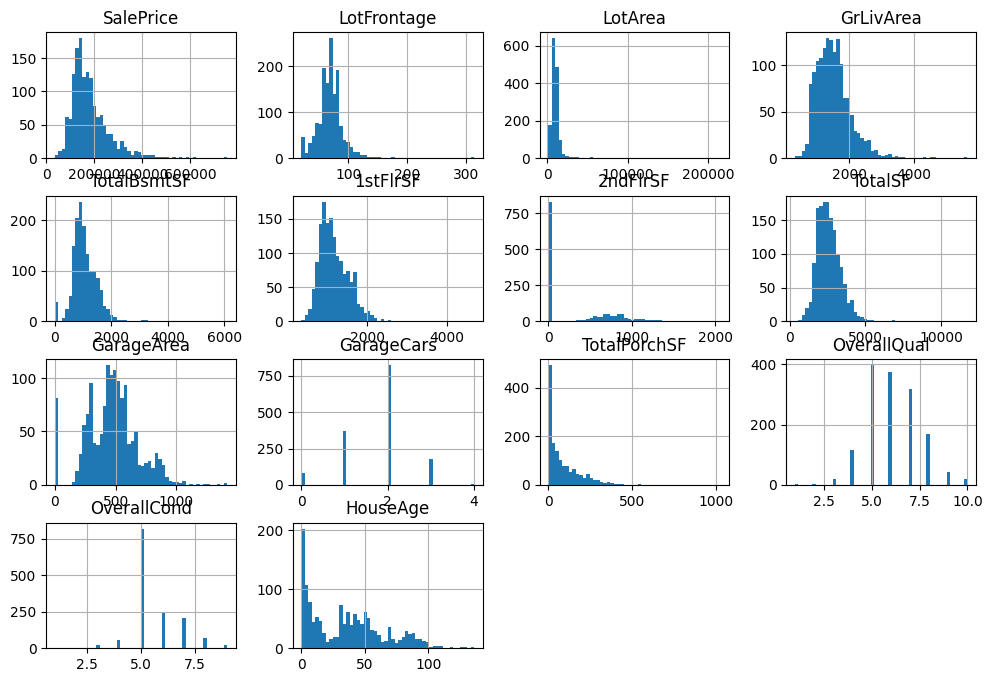

In [26]:
# Histogram	Check skewness & distribution shape
train[numeric_cols].hist(bins=50, figsize=(12,8))
plt.show()

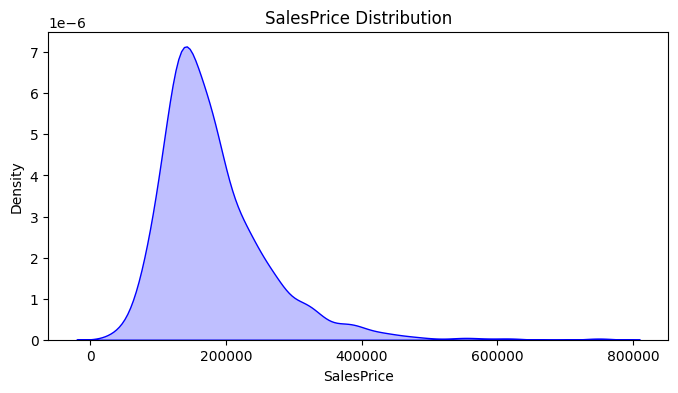

In [27]:
plt.figure(figsize=(8,4))
sns.kdeplot(train['SalePrice'], shade=True, color='blue')
plt.title('SalesPrice Distribution')
plt.xlabel('SalesPrice')
plt.ylabel('Density')
plt.show()

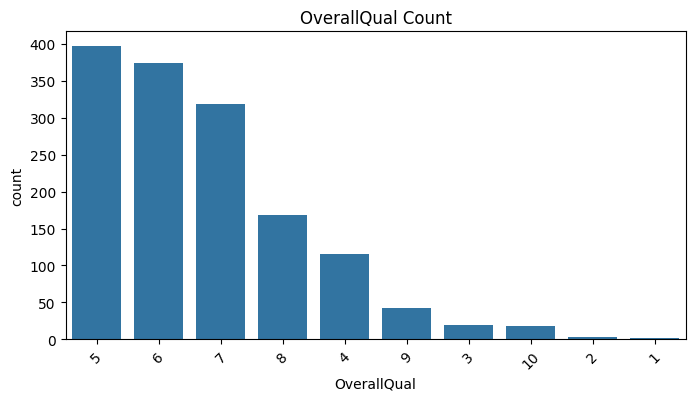

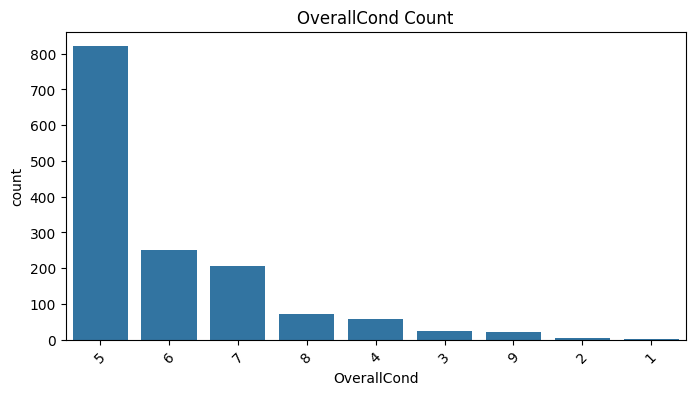

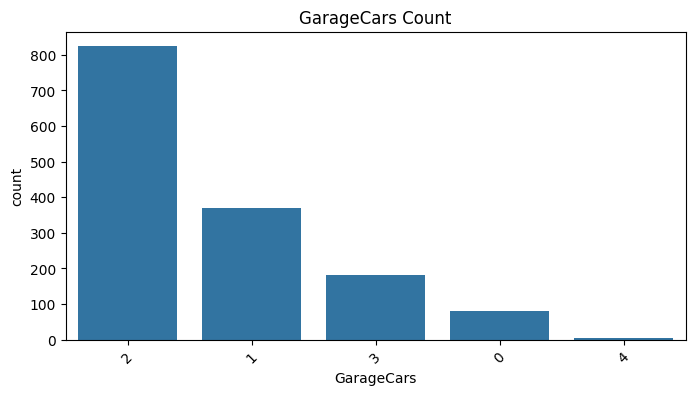

In [28]:
# Frequency of top numerical features
num_cols = ['OverallQual', 'OverallCond', 'GarageCars']

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=train, order=train[col].value_counts().index)
    plt.title(f"{col} Count")
    plt.xticks(rotation=45)
    plt.show()

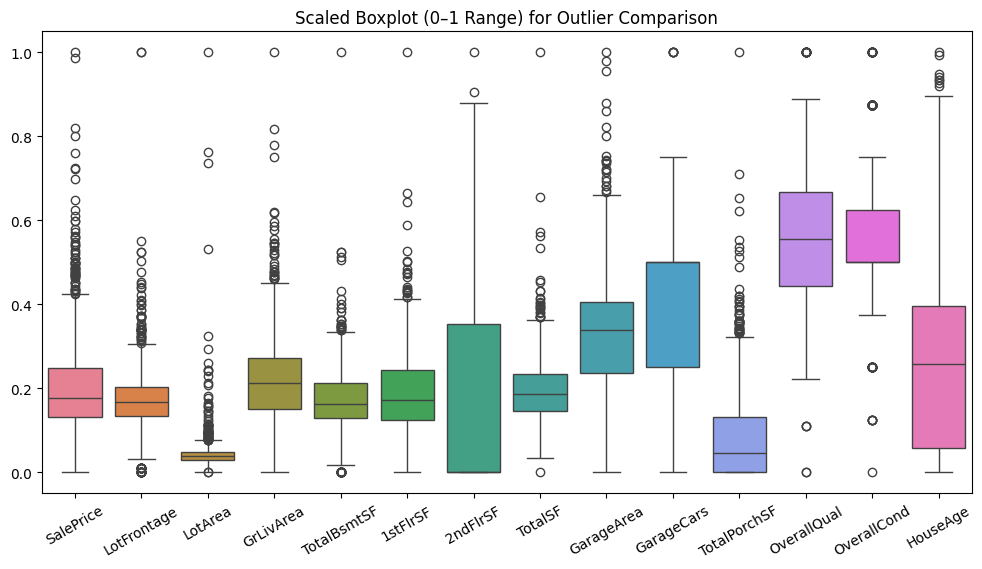

In [29]:
# Scale features only for visualization
scaled = MinMaxScaler().fit_transform(train[numeric_cols])
scaled_df = pd.DataFrame(scaled, columns=numeric_cols)

# Boxplot of scaled features
plt.figure(figsize=(12,6))
sns.boxplot(data=scaled_df)
plt.xticks(rotation=30)
plt.title("Scaled Boxplot (0–1 Range) for Outlier Comparison")
plt.show()

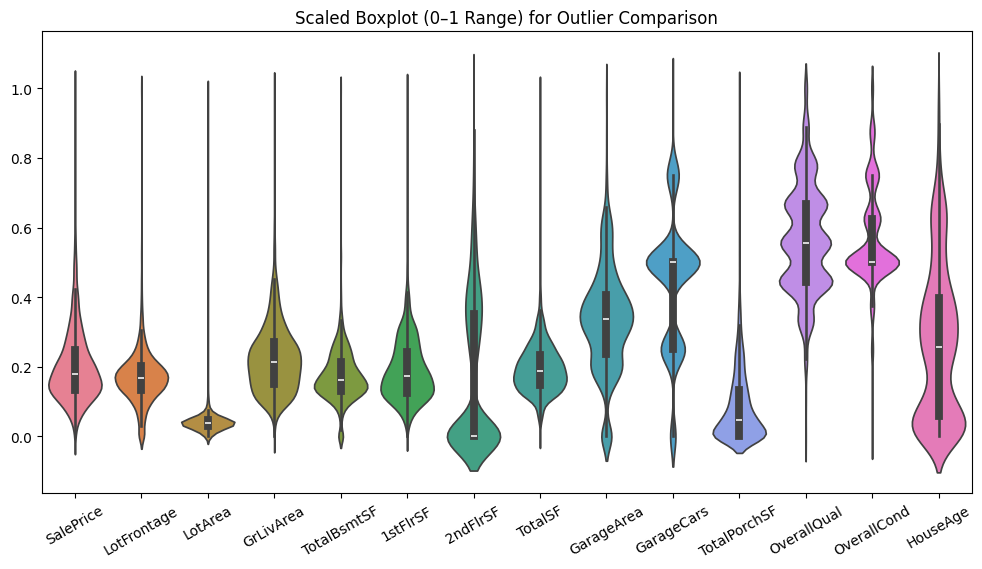

In [30]:
# Violin plot	KDE + boxplot hybrid
plt.figure(figsize=(12,6))
sns.violinplot(data=scaled_df)
plt.xticks(rotation=30)
plt.title("Scaled Boxplot (0–1 Range) for Outlier Comparison")
plt.show()

### **3️⃣ Correlation Analysis**

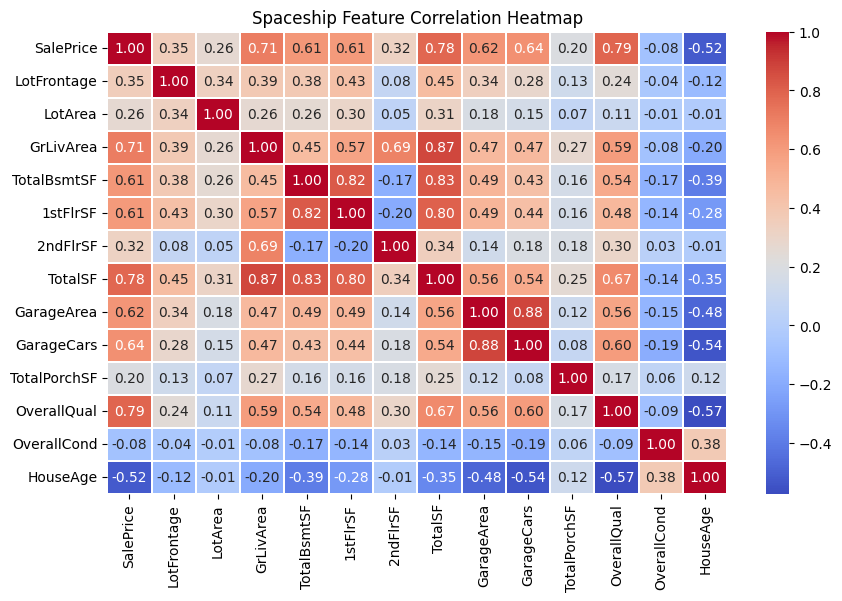

In [31]:
plt.figure(figsize=(10,6))
corr = train[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.2)
plt.title("Spaceship Feature Correlation Heatmap")
plt.show()

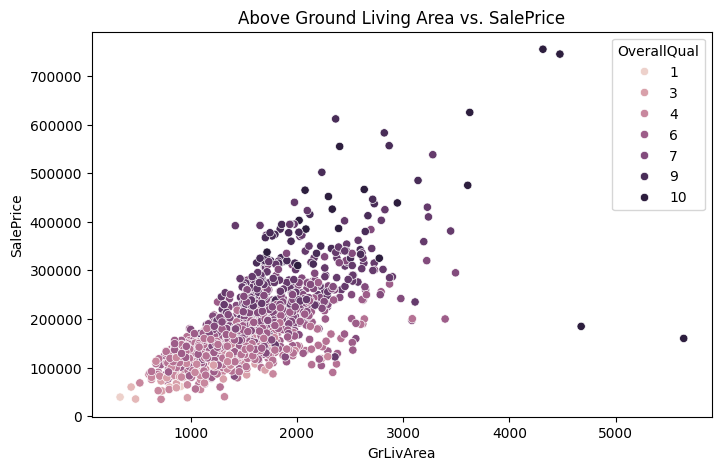

In [32]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='GrLivArea', y='SalePrice', hue='OverallQual', data=train)
plt.title("Above Ground Living Area vs. SalePrice")
plt.show()

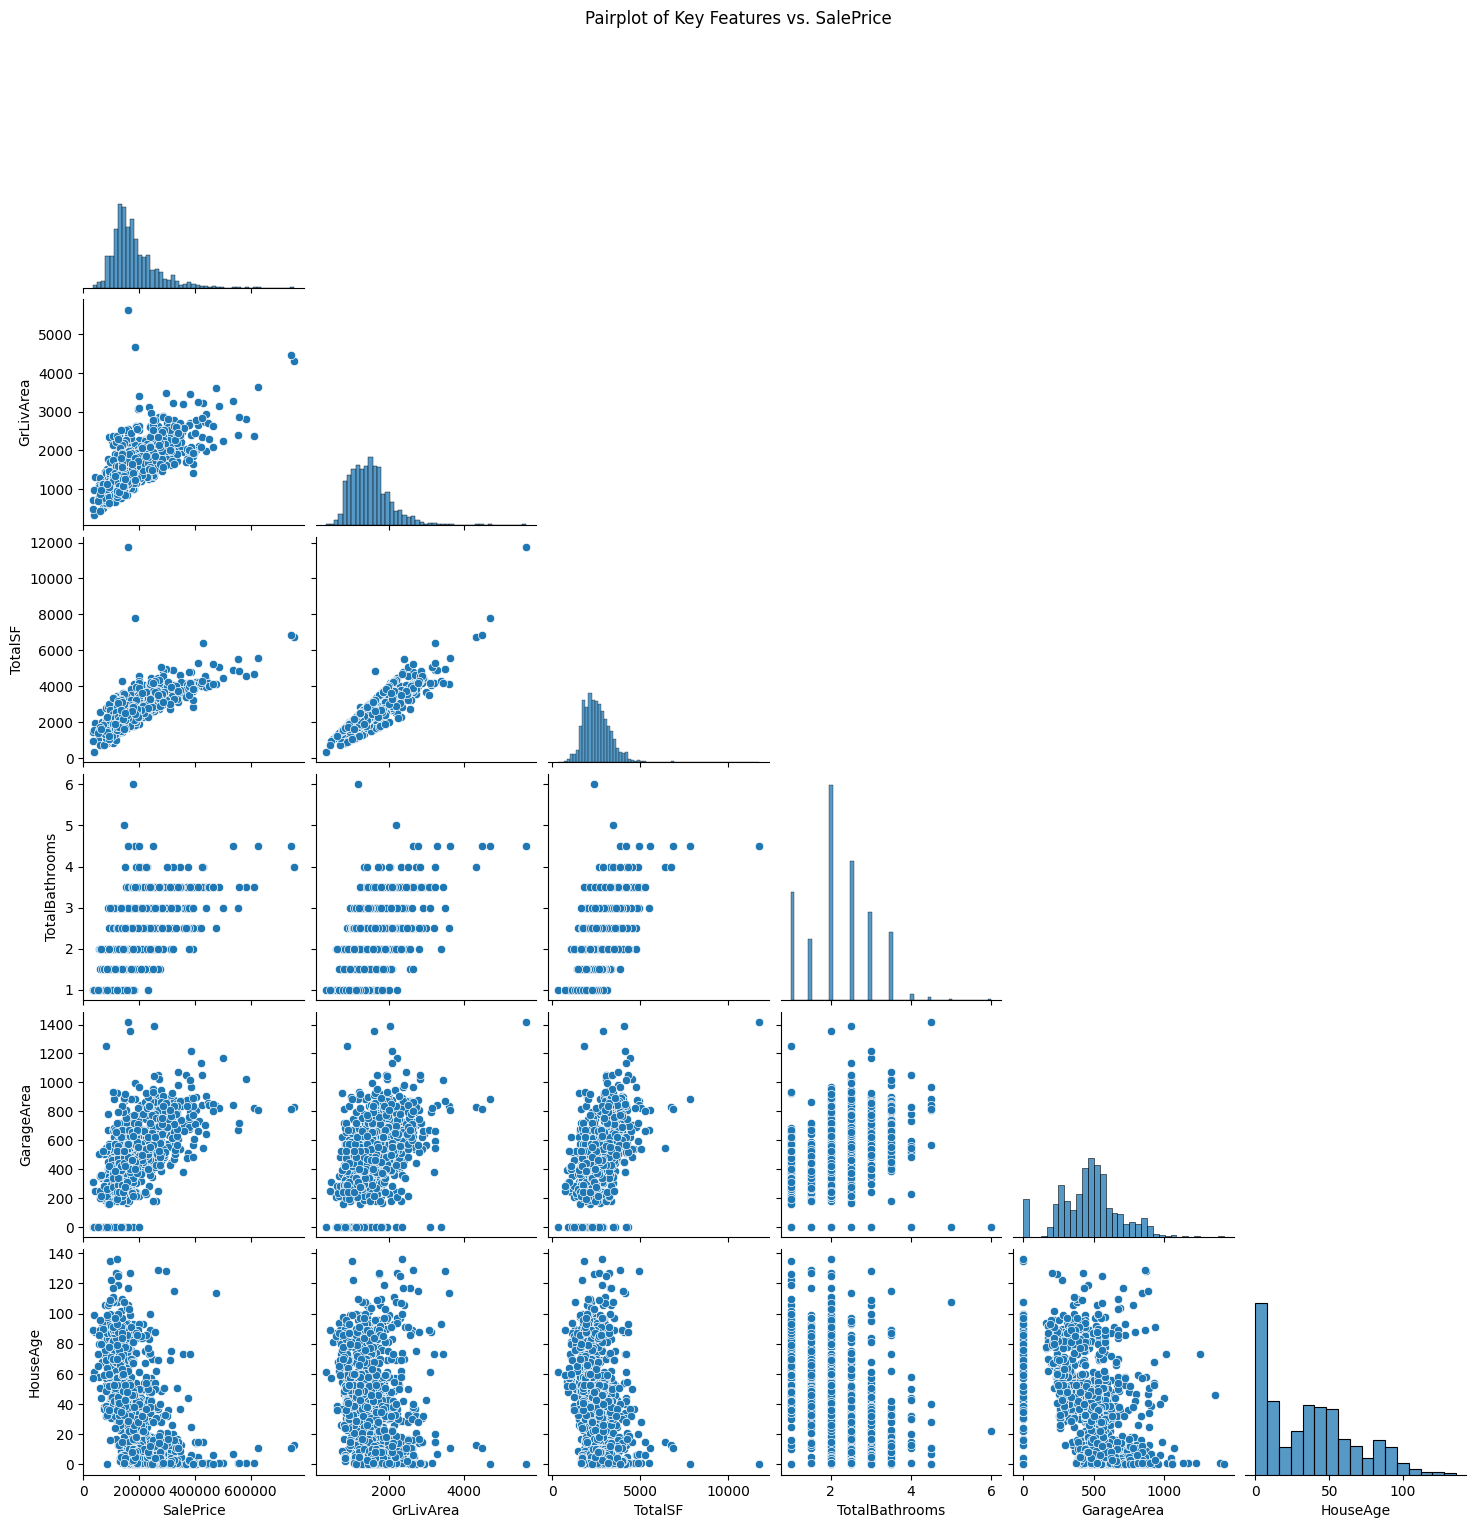

In [33]:
pairplot_features = [
    'SalePrice',
    'GrLivArea',
    'TotalSF',
    'TotalBathrooms',
    'GarageArea',
    'HouseAge'
]
sns.pairplot(train[pairplot_features], corner=True)
plt.suptitle("Pairplot of Key Features vs. SalePrice", y=1.02)
plt.show()

### **4️⃣ Grouped Comparison**

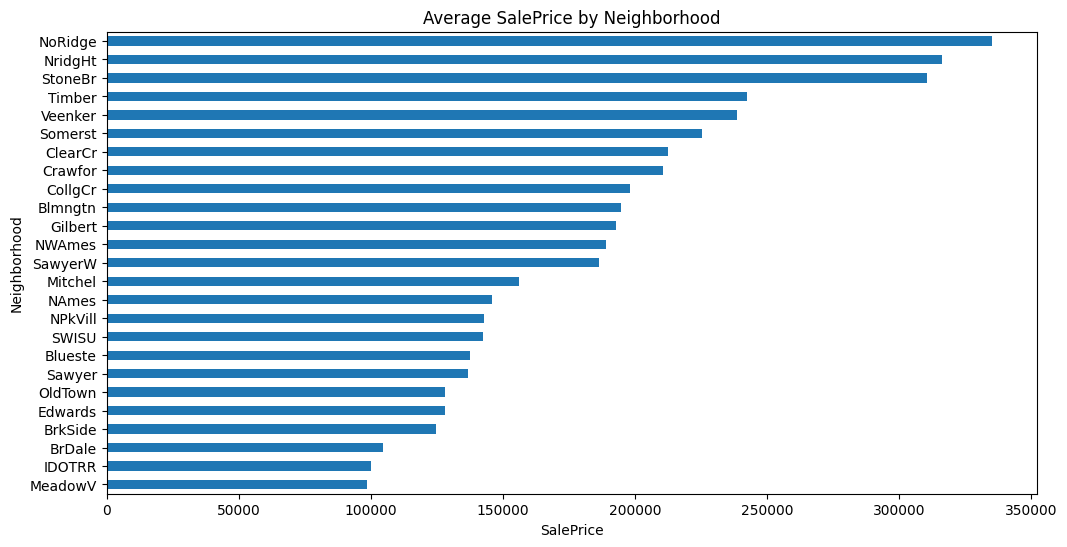

In [34]:
# Compare SalePrice by Neighborhood
plt.figure(figsize=(12,6))
train.groupby('Neighborhood')['SalePrice'].mean().sort_values().plot(kind='barh')
plt.title("Average SalePrice by Neighborhood")
plt.xlabel("SalePrice")
plt.show()

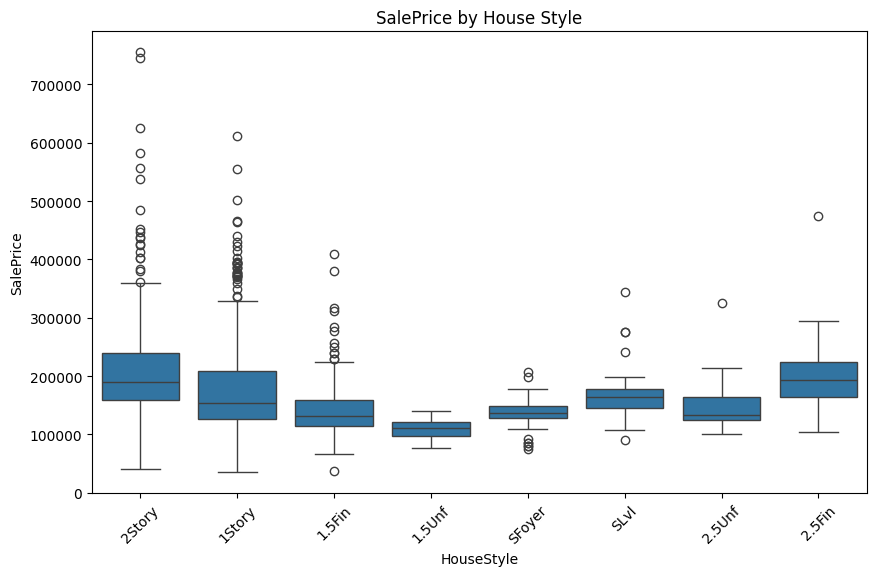

In [35]:
# Compare SalePrice by HouseStyle
plt.figure(figsize=(10,6))
sns.boxplot(x='HouseStyle', y='SalePrice', data=train)
plt.xticks(rotation=45)
plt.title("SalePrice by House Style")
plt.show()

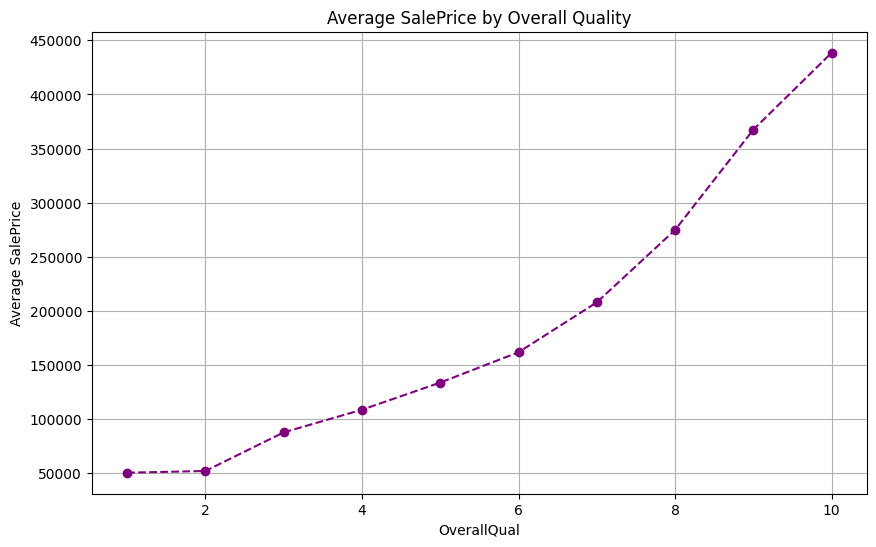

In [36]:
# Group by OverallQual
plt.figure(figsize=(10,6))
train.groupby('OverallQual')['SalePrice'].mean().plot(marker='o', linestyle='--', color='purple')
plt.title("Average SalePrice by Overall Quality")
plt.ylabel("Average SalePrice")
plt.grid(True)
plt.show()

### **5️⃣ Categorical Distributions**

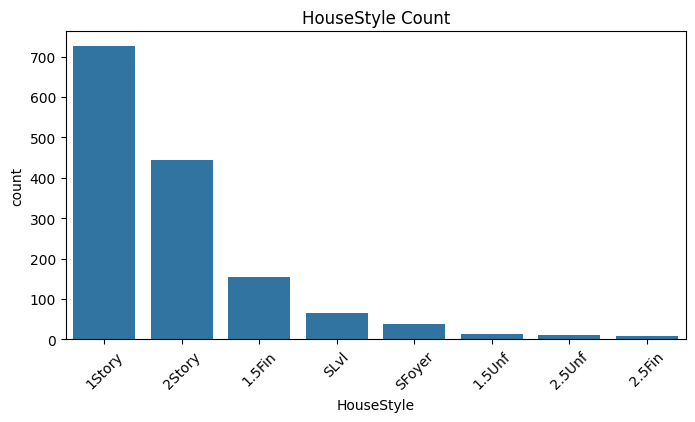

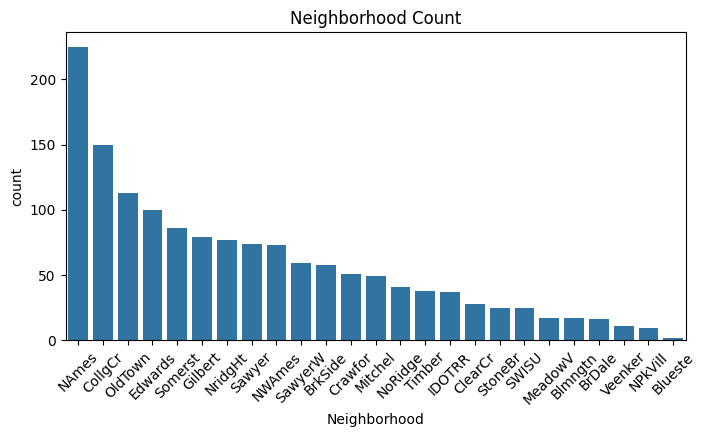

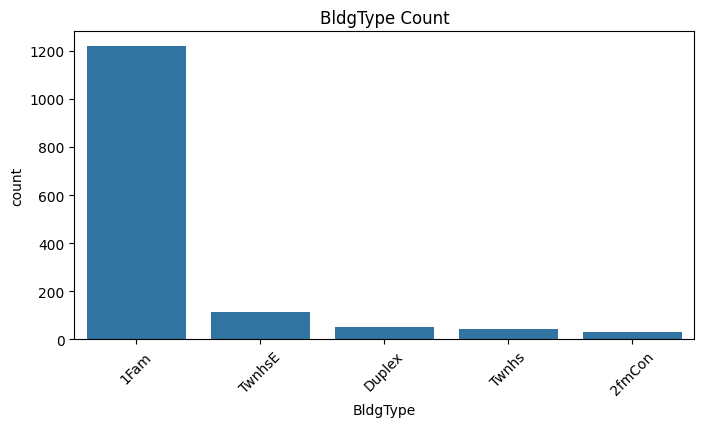

In [37]:
# Frequency of top categories
cat_cols = ['HouseStyle', 'Neighborhood', 'BldgType']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=train, order=train[col].value_counts().index)
    plt.title(f"{col} Count")
    plt.xticks(rotation=45)
    plt.show()

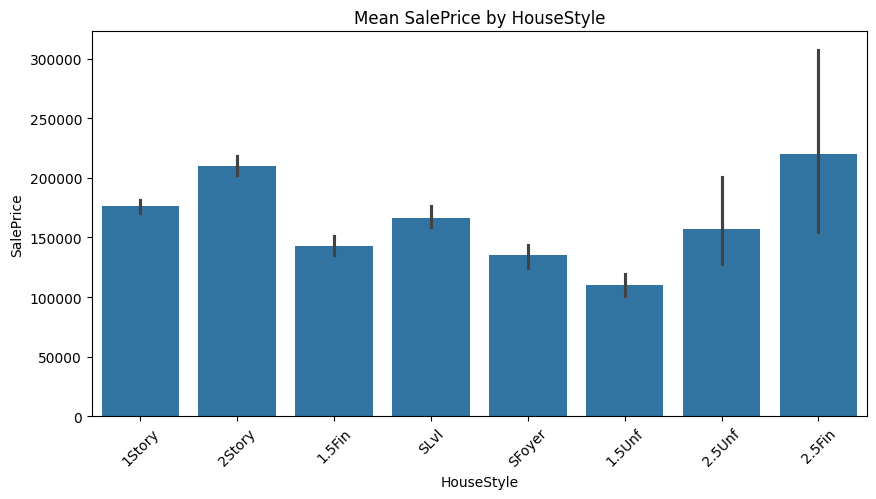

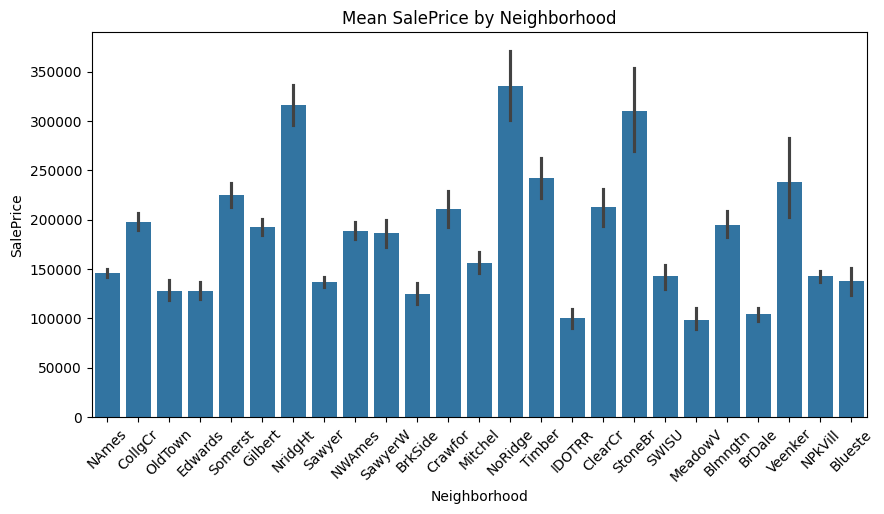

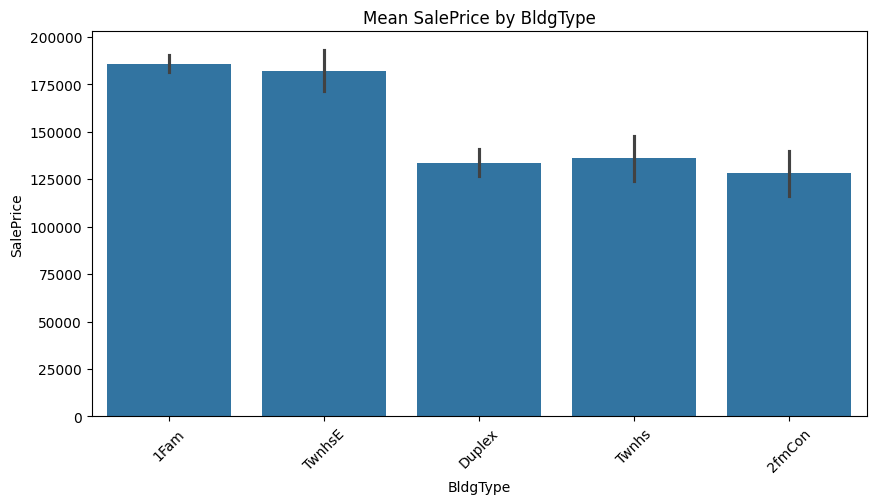

In [38]:
# Impact on target
for col in cat_cols:
    plt.figure(figsize=(10,5))
    sns.barplot(x=col, y='SalePrice', data=train, estimator=np.mean, order=train[col].value_counts().index)
    plt.title(f"Mean SalePrice by {col}")
    plt.xticks(rotation=45)
    plt.show()

### **6️⃣ Target Variable Distribution**

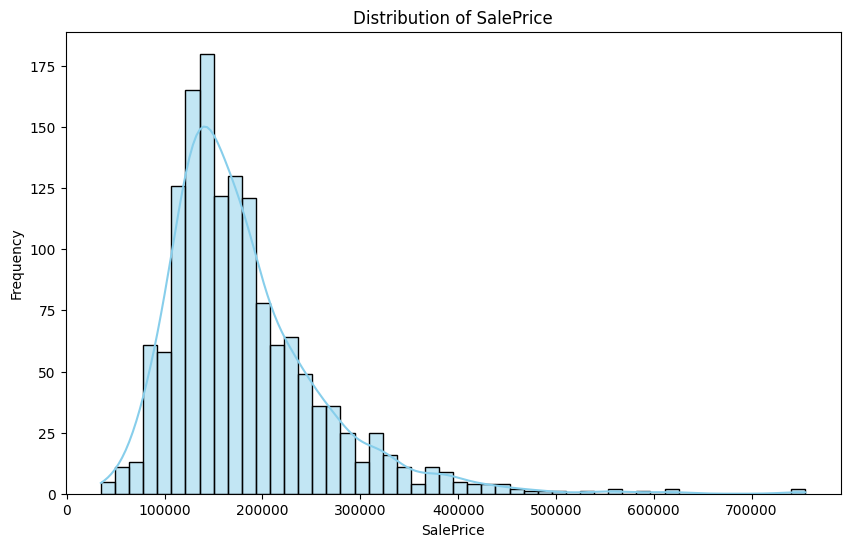

In [39]:
# Histogram with KDE
plt.figure(figsize=(10,6))
sns.histplot(train['SalePrice'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

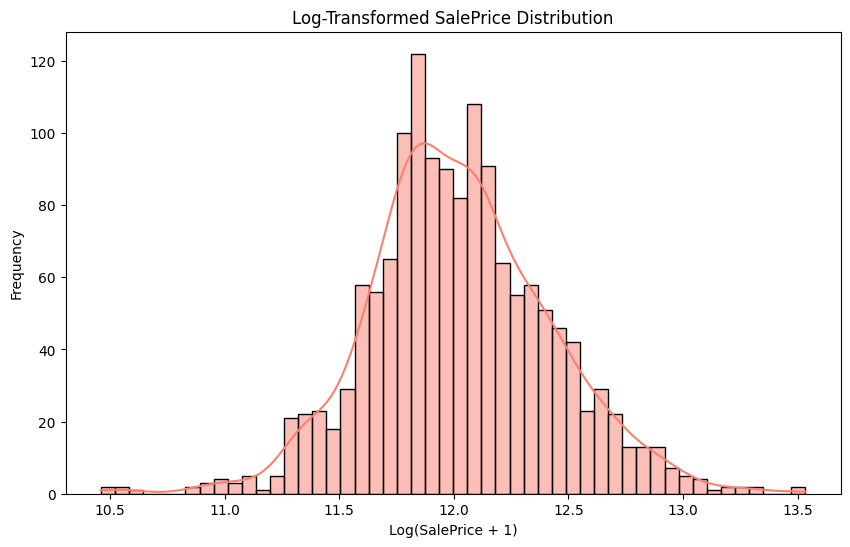

In [40]:
# Log-transformed SalePrice
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(train['SalePrice']), bins=50, kde=True, color='salmon')
plt.title("Log-Transformed SalePrice Distribution")
plt.xlabel("Log(SalePrice + 1)")
plt.ylabel("Frequency")
plt.show()

# **STEP 5: Data Preprocessing**

In [41]:
# first step: seperate numerical and categorical features
num_features = train.select_dtypes(exclude='object').drop('SalePrice', axis=1)
cat_features = train.select_dtypes(include='object')
print("Numeric:", num_features.shape[1], "columns")
print("Categorical:", cat_features.shape[1], "columns")

Numeric: 40 columns
Categorical: 42 columns


In [42]:
def suggest_categorical_encoding(df, threshold=10, max_display=5):
    cat_cols = df.select_dtypes(include='object').columns
    candidates = []

    for col in cat_cols:
        n_unique = df[col].nunique()
        values = df[col].dropna().unique().tolist()
        
        if len(values) > max_display:
            values_display = values[:max_display] + ['...']
        else:
            values_display = values

        if n_unique <= threshold:
            suggestion = 'Possible Ordinal or One-Hot'
        elif n_unique <= 30:
            suggestion = 'Maybe One-Hot / Frequency Encoding'
        else:
            suggestion = 'High Cardinality - Group or Target Encoding'

        candidates.append({
            'Feature': col,
            'UniqueValues': n_unique,
            'SampleValues': values_display,
            'RecommendedStrategy': suggestion
        })

    return pd.DataFrame(candidates).sort_values(by='UniqueValues').reset_index(drop=True)

encoding_recommendations = suggest_categorical_encoding(train)
display(encoding_recommendations)

,Feature,UniqueValues,SampleValues,RecommendedStrategy
0,Street,2,"[Pave, Grvl]",Possible Ordinal or One-Hot
1,CentralAir,2,"[Y, N]",Possible Ordinal or One-Hot
2,PavedDrive,3,"[Y, N, P]",Possible Ordinal or One-Hot
3,Alley,3,"[None, Grvl, Pave]",Possible Ordinal or One-Hot
4,LandSlope,3,"[Gtl, Mod, Sev]",Possible Ordinal or One-Hot
5,LotShape,4,"[Reg, IR1, IR2, IR3]",Possible Ordinal or One-Hot
6,LandContour,4,"[Lvl, Bnk, Low, HLS]",Possible Ordinal or One-Hot
7,MasVnrType,4,"[BrkFace, None, Stone, BrkCmn]",Possible Ordinal or One-Hot
8,PoolQC,4,"[None, Ex, Fa, Gd]",Possible Ordinal or One-Hot
9,ExterQual,4,"[Gd, TA, Ex, Fa]",Possible Ordinal or One-Hot


In [43]:
# encoding ordinal values
# 🔢 1. Define Ordinal Columns
ordinal_cols = [
    'ExterQual', 'ExterCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'HeatingQC',
    'KitchenQual',
    'FireplaceQu',
    'GarageQual', 'GarageCond',
    'PoolQC',
    'Functional',
    'PavedDrive'
]
# ✅ 2. Define Nominal Columns
cat_cols = train.select_dtypes(include='object').columns.tolist()
onehot_cols = [col for col in cat_cols if col not in ordinal_cols]

# 🔧 3. Create the Encoders
ordinal_encoder = OrdinalEncoder()
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 🔄 4. Build the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', ordinal_encoder, ordinal_cols),
        ('onehot', onehot_encoder, onehot_cols)
    ],
    remainder='passthrough'  # Keep numerical features untouched
)

X = train.drop(columns='SalePrice')  # exclude the target
y = train['SalePrice']               # target variable

# Apply encoding
X_encoded = preprocessor.fit_transform(X)

encoded_columns = preprocessor.get_feature_names_out()
X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_columns)
X_encoded_df.head()

,ordinal__ExterQual,ordinal__ExterCond,ordinal__BsmtQual,ordinal__BsmtCond,ordinal__BsmtExposure,ordinal__HeatingQC,ordinal__KitchenQual,ordinal__FireplaceQu,ordinal__GarageQual,ordinal__GarageCond,ordinal__PoolQC,ordinal__Functional,ordinal__PavedDrive,onehot__MSZoning_C (all),onehot__MSZoning_FV,onehot__MSZoning_RH,onehot__MSZoning_RL,onehot__MSZoning_RM,onehot__Street_Grvl,onehot__Street_Pave,onehot__Alley_Grvl,onehot__Alley_None,onehot__Alley_Pave,onehot__LotShape_IR1,onehot__LotShape_IR2,onehot__LotShape_IR3,onehot__LotShape_Reg,onehot__LandContour_Bnk,onehot__LandContour_HLS,onehot__LandContour_Low,onehot__LandContour_Lvl,onehot__LotConfig_Corner,onehot__LotConfig_CulDSac,onehot__LotConfig_FR2,onehot__LotConfig_FR3,onehot__LotConfig_Inside,onehot__LandSlope_Gtl,onehot__LandSlope_Mod,onehot__LandSlope_Sev,onehot__Neighborhood_Blmngtn,onehot__Neighborhood_Blueste,onehot__Neighborhood_BrDale,onehot__Neighborhood_BrkSide,onehot__Neighborhood_ClearCr,onehot__Neighborhood_CollgCr,onehot__Neighborhood_Crawfor,onehot__Neighborhood_Edwards,onehot__Neighborhood_Gilbert,onehot__Neighborhood_IDOTRR,onehot__Neighborhood_MeadowV,onehot__Neighborhood_Mitchel,onehot__Neighborhood_NAmes,onehot__Neighborhood_NPkVill,onehot__Neighborhood_NWAmes,onehot__Neighborhood_NoRidge,onehot__Neighborhood_NridgHt,onehot__Neighborhood_OldTown,onehot__Neighborhood_SWISU,onehot__Neighborhood_Sawyer,onehot__Neighborhood_SawyerW,onehot__Neighborhood_Somerst,onehot__Neighborhood_StoneBr,onehot__Neighborhood_Timber,onehot__Neighborhood_Veenker,onehot__Condition1_Artery,onehot__Condition1_Feedr,onehot__Condition1_Norm,onehot__Condition1_PosA,onehot__Condition1_PosN,onehot__Condition1_RRAe,onehot__Condition1_RRAn,onehot__Condition1_RRNe,onehot__Condition1_RRNn,onehot__Condition2_Artery,onehot__Condition2_Feedr,onehot__Condition2_Norm,onehot__Condition2_PosA,onehot__Condition2_PosN,onehot__Condition2_RRAe,onehot__Condition2_RRAn,onehot__Condition2_RRNn,onehot__BldgType_1Fam,onehot__BldgType_2fmCon,onehot__BldgType_Duplex,onehot__BldgType_Twnhs,onehot__BldgType_TwnhsE,onehot__HouseStyle_1.5Fin,onehot__HouseStyle_1.5Unf,onehot__HouseStyle_1Story,onehot__HouseStyle_2.5Fin,onehot__HouseStyle_2.5Unf,onehot__HouseStyle_2Story,onehot__HouseStyle_SFoyer,onehot__HouseStyle_SLvl,onehot__RoofStyle_Flat,onehot__RoofStyle_Gable,onehot__RoofStyle_Gambrel,onehot__RoofStyle_Hip,onehot__RoofStyle_Mansard,onehot__RoofStyle_Shed,onehot__RoofMatl_ClyTile,onehot__RoofMatl_CompShg,onehot__RoofMatl_Membran,onehot__RoofMatl_Metal,onehot__RoofMatl_Roll,onehot__RoofMatl_Tar&Grv,onehot__RoofMatl_WdShake,onehot__RoofMatl_WdShngl,onehot__Exterior1st_AsbShng,onehot__Exterior1st_AsphShn,onehot__Exterior1st_BrkComm,onehot__Exterior1st_BrkFace,onehot__Exterior1st_CBlock,onehot__Exterior1st_CemntBd,onehot__Exterior1st_HdBoard,onehot__Exterior1st_ImStucc,onehot__Exterior1st_MetalSd,onehot__Exterior1st_Plywood,onehot__Exterior1st_Stone,onehot__Exterior1st_Stucco,onehot__Exterior1st_VinylSd,onehot__Exterior1st_Wd Sdng,onehot__Exterior1st_WdShing,onehot__Exterior2nd_AsbShng,onehot__Exterior2nd_AsphShn,onehot__Exterior2nd_Brk Cmn,onehot__Exterior2nd_BrkFace,onehot__Exterior2nd_CBlock,onehot__Exterior2nd_CmentBd,onehot__Exterior2nd_HdBoard,onehot__Exterior2nd_ImStucc,onehot__Exterior2nd_MetalSd,onehot__Exterior2nd_Other,onehot__Exterior2nd_Plywood,onehot__Exterior2nd_Stone,onehot__Exterior2nd_Stucco,onehot__Exterior2nd_VinylSd,onehot__Exterior2nd_Wd Sdng,onehot__Exterior2nd_Wd Shng,onehot__MasVnrType_BrkCmn,onehot__MasVnrType_BrkFace,onehot__MasVnrType_None,onehot__MasVnrType_Stone,onehot__Foundation_BrkTil,onehot__Foundation_CBlock,onehot__Foundation_PConc,onehot__Foundation_Slab,onehot__Foundation_Stone,onehot__Foundation_Wood,onehot__BsmtFinType1_ALQ,onehot__BsmtFinType1_BLQ,onehot__BsmtFinType1_GLQ,onehot__BsmtFinType1_LwQ,onehot__BsmtFinType1_None,onehot__BsmtFinType1_Rec,onehot__BsmtFinType1_Unf,onehot__BsmtFinType2_ALQ,onehot__BsmtFinType2_BLQ,onehot__BsmtFinType2_GLQ,onehot__BsmtFinType2_LwQ,

# **Step 6: Feature Selection**
- We use multiple methods to determine which features should be kept and which ones can be dropped.

In [44]:
X_encoded_df.head()

,ordinal__ExterQual,ordinal__ExterCond,ordinal__BsmtQual,ordinal__BsmtCond,ordinal__BsmtExposure,ordinal__HeatingQC,ordinal__KitchenQual,ordinal__FireplaceQu,ordinal__GarageQual,ordinal__GarageCond,ordinal__PoolQC,ordinal__Functional,ordinal__PavedDrive,onehot__MSZoning_C (all),onehot__MSZoning_FV,onehot__MSZoning_RH,onehot__MSZoning_RL,onehot__MSZoning_RM,onehot__Street_Grvl,onehot__Street_Pave,onehot__Alley_Grvl,onehot__Alley_None,onehot__Alley_Pave,onehot__LotShape_IR1,onehot__LotShape_IR2,onehot__LotShape_IR3,onehot__LotShape_Reg,onehot__LandContour_Bnk,onehot__LandContour_HLS,onehot__LandContour_Low,onehot__LandContour_Lvl,onehot__LotConfig_Corner,onehot__LotConfig_CulDSac,onehot__LotConfig_FR2,onehot__LotConfig_FR3,onehot__LotConfig_Inside,onehot__LandSlope_Gtl,onehot__LandSlope_Mod,onehot__LandSlope_Sev,onehot__Neighborhood_Blmngtn,onehot__Neighborhood_Blueste,onehot__Neighborhood_BrDale,onehot__Neighborhood_BrkSide,onehot__Neighborhood_ClearCr,onehot__Neighborhood_CollgCr,onehot__Neighborhood_Crawfor,onehot__Neighborhood_Edwards,onehot__Neighborhood_Gilbert,onehot__Neighborhood_IDOTRR,onehot__Neighborhood_MeadowV,onehot__Neighborhood_Mitchel,onehot__Neighborhood_NAmes,onehot__Neighborhood_NPkVill,onehot__Neighborhood_NWAmes,onehot__Neighborhood_NoRidge,onehot__Neighborhood_NridgHt,onehot__Neighborhood_OldTown,onehot__Neighborhood_SWISU,onehot__Neighborhood_Sawyer,onehot__Neighborhood_SawyerW,onehot__Neighborhood_Somerst,onehot__Neighborhood_StoneBr,onehot__Neighborhood_Timber,onehot__Neighborhood_Veenker,onehot__Condition1_Artery,onehot__Condition1_Feedr,onehot__Condition1_Norm,onehot__Condition1_PosA,onehot__Condition1_PosN,onehot__Condition1_RRAe,onehot__Condition1_RRAn,onehot__Condition1_RRNe,onehot__Condition1_RRNn,onehot__Condition2_Artery,onehot__Condition2_Feedr,onehot__Condition2_Norm,onehot__Condition2_PosA,onehot__Condition2_PosN,onehot__Condition2_RRAe,onehot__Condition2_RRAn,onehot__Condition2_RRNn,onehot__BldgType_1Fam,onehot__BldgType_2fmCon,onehot__BldgType_Duplex,onehot__BldgType_Twnhs,onehot__BldgType_TwnhsE,onehot__HouseStyle_1.5Fin,onehot__HouseStyle_1.5Unf,onehot__HouseStyle_1Story,onehot__HouseStyle_2.5Fin,onehot__HouseStyle_2.5Unf,onehot__HouseStyle_2Story,onehot__HouseStyle_SFoyer,onehot__HouseStyle_SLvl,onehot__RoofStyle_Flat,onehot__RoofStyle_Gable,onehot__RoofStyle_Gambrel,onehot__RoofStyle_Hip,onehot__RoofStyle_Mansard,onehot__RoofStyle_Shed,onehot__RoofMatl_ClyTile,onehot__RoofMatl_CompShg,onehot__RoofMatl_Membran,onehot__RoofMatl_Metal,onehot__RoofMatl_Roll,onehot__RoofMatl_Tar&Grv,onehot__RoofMatl_WdShake,onehot__RoofMatl_WdShngl,onehot__Exterior1st_AsbShng,onehot__Exterior1st_AsphShn,onehot__Exterior1st_BrkComm,onehot__Exterior1st_BrkFace,onehot__Exterior1st_CBlock,onehot__Exterior1st_CemntBd,onehot__Exterior1st_HdBoard,onehot__Exterior1st_ImStucc,onehot__Exterior1st_MetalSd,onehot__Exterior1st_Plywood,onehot__Exterior1st_Stone,onehot__Exterior1st_Stucco,onehot__Exterior1st_VinylSd,onehot__Exterior1st_Wd Sdng,onehot__Exterior1st_WdShing,onehot__Exterior2nd_AsbShng,onehot__Exterior2nd_AsphShn,onehot__Exterior2nd_Brk Cmn,onehot__Exterior2nd_BrkFace,onehot__Exterior2nd_CBlock,onehot__Exterior2nd_CmentBd,onehot__Exterior2nd_HdBoard,onehot__Exterior2nd_ImStucc,onehot__Exterior2nd_MetalSd,onehot__Exterior2nd_Other,onehot__Exterior2nd_Plywood,onehot__Exterior2nd_Stone,onehot__Exterior2nd_Stucco,onehot__Exterior2nd_VinylSd,onehot__Exterior2nd_Wd Sdng,onehot__Exterior2nd_Wd Shng,onehot__MasVnrType_BrkCmn,onehot__MasVnrType_BrkFace,onehot__MasVnrType_None,onehot__MasVnrType_Stone,onehot__Foundation_BrkTil,onehot__Foundation_CBlock,onehot__Foundation_PConc,onehot__Foundation_Slab,onehot__Foundation_Stone,onehot__Foundation_Wood,onehot__BsmtFinType1_ALQ,onehot__BsmtFinType1_BLQ,onehot__BsmtFinType1_GLQ,onehot__BsmtFinType1_LwQ,onehot__BsmtFinType1_None,onehot__BsmtFinType1_Rec,onehot__BsmtFinType1_Unf,onehot__BsmtFinType2_ALQ,onehot__BsmtFinType2_BLQ,onehot__BsmtFinType2_GLQ,onehot__BsmtFinType2_LwQ,

In [45]:
# Add back SalePrice for correlation
X_encoded_df['SalePrice'] = y.values

# Now compute correlation
correlation = X_encoded_df.corr()['SalePrice'].sort_values(ascending=False)
display(correlation)

SalePrice                   1.000000
remainder__OverallQual      0.790982
remainder__TotalSF          0.782260
remainder__GrLivArea        0.708624
remainder__GarageCars       0.640409
                              ...   
onehot__GarageFinish_Unf   -0.410608
remainder__HouseAge        -0.523350
ordinal__KitchenQual       -0.589189
ordinal__BsmtQual          -0.593734
ordinal__ExterQual         -0.636884
Name: SalePrice, Length: 253, dtype: float64

In [46]:
# Keep only top correlated features
top_features = correlation[abs(correlation) > 0.05].index.tolist()
print(top_features)

['SalePrice', 'remainder__OverallQual', 'remainder__TotalSF', 'remainder__GrLivArea', 'remainder__GarageCars', 'remainder__TotalBathrooms', 'remainder__GarageArea', 'remainder__TotalBsmtSF', 'remainder__1stFlrSF', 'remainder__FullBath', 'remainder__TotRmsAbvGrd', 'remainder__YearBuilt', 'remainder__YearRemodAdd', 'onehot__Foundation_PConc', 'remainder__MasVnrArea', 'remainder__Fireplaces', 'onehot__BsmtFinType1_GLQ', 'onehot__GarageFinish_Fin', 'onehot__Neighborhood_NridgHt', 'remainder__BsmtFinSF1', 'onehot__SaleType_New', 'onehot__SaleCondition_Partial', 'remainder__LotFrontage', 'onehot__GarageType_Attchd', 'onehot__MasVnrType_Stone', 'onehot__Neighborhood_NoRidge', 'remainder__WoodDeckSF', 'remainder__2ndFlrSF', 'remainder__OpenPorchSF', 'onehot__Exterior2nd_VinylSd', 'onehot__Exterior1st_VinylSd', 'remainder__HalfBath', 'remainder__LotArea', 'remainder__GarageYrBlt', 'onehot__CentralAir_Y', 'ordinal__GarageCond', 'onehot__MSZoning_RL', 'onehot__HouseStyle_2Story', 'onehot__Electri

# **STEP 7: Modeling**

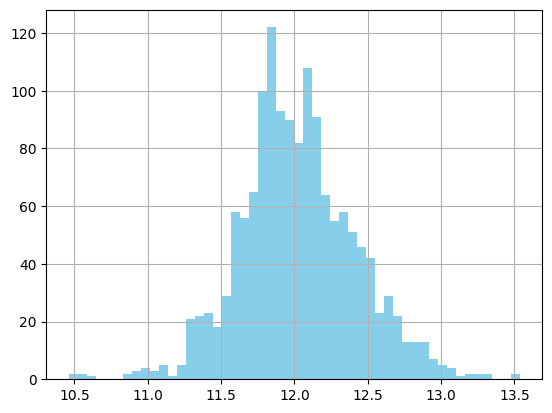

<Axes: >

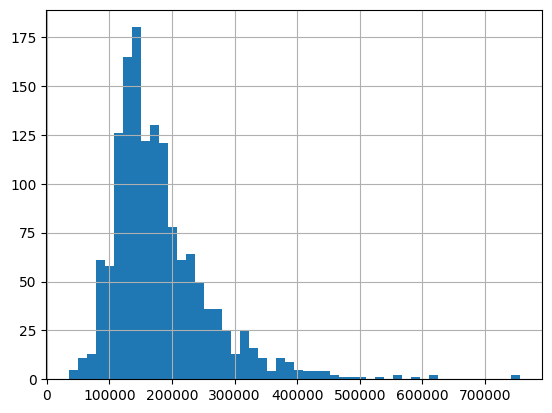

In [69]:
# log transformation vs normal values
np.log1p(X_encoded_df['SalePrice']).hist(bins=50, color='skyblue')
plt.show()
X_encoded_df['SalePrice'].hist(bins=50)

In [70]:
# Splitting Data into Training, Validation, and Test Sets

# Define Features (X) and Target (y)
X_train_selected = X_encoded_df[top_features].drop(columns='SalePrice')
y = np.log1p(X_encoded_df['SalePrice'])  # log1p = log(x+1), safe for 0
print(X_train_selected.shape, y.shape)

(1460, 159) (1460,)


In [71]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_selected, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

(1168, 159) (292, 159) (1168,) (292,)


In [72]:
# Align test columns to match training columns
test_df = test.copy()
X_test_encoded = preprocessor.transform(test_df)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=preprocessor.get_feature_names_out())
X_test_selected = X_test_encoded_df.reindex(columns=X_train_selected.columns, fill_value=0)
X_test_selected.head()

,remainder__OverallQual,remainder__TotalSF,remainder__GrLivArea,remainder__GarageCars,remainder__TotalBathrooms,remainder__GarageArea,remainder__TotalBsmtSF,remainder__1stFlrSF,remainder__FullBath,remainder__TotRmsAbvGrd,remainder__YearBuilt,remainder__YearRemodAdd,onehot__Foundation_PConc,remainder__MasVnrArea,remainder__Fireplaces,onehot__BsmtFinType1_GLQ,onehot__GarageFinish_Fin,onehot__Neighborhood_NridgHt,remainder__BsmtFinSF1,onehot__SaleType_New,onehot__SaleCondition_Partial,remainder__LotFrontage,onehot__GarageType_Attchd,onehot__MasVnrType_Stone,onehot__Neighborhood_NoRidge,remainder__WoodDeckSF,remainder__2ndFlrSF,remainder__OpenPorchSF,onehot__Exterior2nd_VinylSd,onehot__Exterior1st_VinylSd,remainder__HalfBath,remainder__LotArea,remainder__GarageYrBlt,onehot__CentralAir_Y,ordinal__GarageCond,onehot__MSZoning_RL,onehot__HouseStyle_2Story,onehot__Electrical_SBrkr,onehot__RoofStyle_Hip,onehot__GarageType_BuiltIn,ordinal__PavedDrive,remainder__BsmtFullBath,onehot__LotShape_IR1,onehot__Neighborhood_StoneBr,remainder__BsmtUnfSF,ordinal__GarageQual,onehot__MasVnrType_BrkFace,remainder__TotalPorchSF,onehot__Fence_None,onehot__GarageFinish_RFn,onehot__RoofMatl_WdShngl,remainder__BedroomAbvGr,onehot__LotConfig_CulDSac,onehot__Neighborhood_Somerst,onehot__BldgType_1Fam,onehot__Exterior1st_CemntBd,onehot__Exterior2nd_CmentBd,onehot__Neighborhood_Timber,onehot__LotShape_IR2,onehot__Alley_None,onehot__LandContour_HLS,onehot__BsmtFinType2_Unf,ordinal__ExterCond,ordinal__Functional,onehot__Condition1_Norm,remainder__ScreenPorch,onehot__Heating_GasA,remainder__PoolArea,ordinal__BsmtCond,onehot__MSZoning_FV,onehot__Exterior2nd_ImStucc,onehot__Neighborhood_CollgCr,onehot__MiscFeature_None,onehot__Neighborhood_Crawfor,onehot__Neighborhood_Veenker,onehot__Neighborhood_ClearCr,onehot__SaleCondition_AdjLand,onehot__LandSlope_Gtl,onehot__Fence_MnWw,onehot__Exterior1st_BrkComm,onehot__Exterior1st_WdShing,onehot__Exterior2nd_Plywood,onehot__BsmtFinType2_BLQ,onehot__Neighborhood_Mitchel,onehot__Heating_Wall,onehot__HouseStyle_1Story,onehot__Neighborhood_SWISU,onehot__MSZoning_RH,onehot__Exterior2nd_HdBoard,onehot__MiscFeature_Shed,onehot__GarageType_CarPort,remainder__OverallCond,onehot__LotConfig_Inside,onehot__SaleType_COD,onehot__BsmtFinType1_Unf,remainder__MSSubClass,onehot__BsmtFinType1_LwQ,onehot__HouseStyle_1.5Unf,onehot__Heating_Grav,onehot__HouseStyle_SFoyer,onehot__Exterior1st_HdBoard,ordinal__FireplaceQu,onehot__BldgType_2fmCon,onehot__BldgType_Twnhs,onehot__Exterior2nd_AsbShng,onehot__Fence_GdWo,onehot__LandContour_Bnk,onehot__Neighborhood_BrDale,onehot__BsmtFinType1_ALQ,onehot__RoofMatl_CompShg,onehot__Condition1_Artery,onehot__Exterior1st_AsbShng,onehot__MSZoning_C (all),onehot__Neighborhood_MeadowV,onehot__BldgType_Duplex,onehot__Condition1_Feedr,onehot__SaleCondition_Abnorml,onehot__Foundation_Slab,ordinal__PoolQC,onehot__Electrical_FuseF,onehot__Neighborhood_Sawyer,remainder__EnclosedPorch,onehot__BsmtFinType1_BLQ,onehot__BsmtFinType1_Rec,remainder__KitchenAbvGr,onehot__Alley_Grvl,onehot__Fence_MnPrv,onehot__Neighborhood_BrkSide,onehot__BsmtFinType2_None,onehot__BsmtFinType1_None,onehot__SaleCondition_Normal,onehot__Exterior1st_Wd Sdng,onehot__Exterior2nd_Wd Sdng,onehot__Exterior2nd_MetalSd,onehot__HouseStyle_1.5Fin,onehot__Neighborhood_IDOTRR,onehot__Exterior1st_MetalSd,onehot__Neighborhood_Edwards,onehot__Neighborhood_NAmes,onehot__Neighborhood_OldTown,onehot__Electrical_FuseA,onehot__Foundation_BrkTil,onehot__RoofStyle_Gable,onehot__GarageFinish_None,onehot__GarageType_None,onehot__SaleType_WD,onehot__CentralAir_N,onehot__LotShape_Reg,onehot__MSZoning_RM,ordinal__BsmtExposure,onehot__Foundation_CBlock,onehot__GarageType_Detchd,onehot__MasVnrType_None,ordinal__HeatingQC,onehot__GarageFinish_Unf,remainder__HouseAge,ordinal__KitchenQual,ordinal__BsmtQual,ordinal__ExterQual
0,5.0,1778.0,896.0,1.0,1.0,730.0,882.0,896.0,1.0,5.0,1961.0,1961.0,0.0,0.0,0.0,0.0,0.0,0.0,468.0,0.0,0.0,80.0,1.0,0.0,0.0,140.0,0.0,0.0,1.0,1.0,0.0,11622.0

In [73]:
# Step 1: Identify continuous features (typically from 'remainder__' columns)
num_cols = [col for col in X_train.columns if 'remainder__' in col]

# Step 2: Fit only on train (avoid data leakage)
scaler = MinMaxScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test_selected[num_cols] = scaler.transform(X_test_selected[num_cols])

# Step 3: Save the scaler
joblib.dump(scaler, "scaler.pkl")
print("Scaler saved successfully!")

Scaler saved successfully!


In [74]:
models = {
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=30, max_features="sqrt", random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1)
}

regression_results = []

for name, model in models.items():
    print(f"🔍 Modeling: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = mean_squared_error(y_val, y_pred, squared=False)  # RMSE = sqrt(MSE)
    r2 = r2_score(y_val, y_pred)

    summary = {
        "Model": name,
        "R² Score": round(r2, 4),
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
    }

    regression_results.append(summary)

regression_df = pd.DataFrame(regression_results)
regression_df.sort_values(by="R² Score", ascending=False)

🔍 Modeling: Ridge Regression
🔍 Modeling: Random Forest
🔍 Modeling: Decision Tree
🔍 Modeling: Gradient Boosting
🔍 Modeling: AdaBoost
🔍 Modeling: KNN
🔍 Modeling: XGBoost
🔍 Modeling: LightGBM


,Model,R² Score,MAE,RMSE
0,Ridge Regression,0.9102,0.09,0.13
3,Gradient Boosting,0.9050,0.09,0.13
7,LightGBM,0.8937,0.09,0.14
6,XGBoost,0.8799,0.10,0.15
1,Random Forest,0.8664,0.10,0.16
4,AdaBoost,0.8356,0.13,0.18
2,Decision Tree,0.7495,0.15,0.22
5,KNN,0.7150,0.16,0.23


In [75]:
# Find the best model based on F1 Score
best_model_name = regression_df.sort_values(by="R² Score", ascending=False).iloc[0]['Model']
# best_model_name = regression_df.loc[regression_df['R² Score'].idxmax(), 'Model']
best_model = models[best_model_name]
# Predict on validation set
y_pred = best_model.predict(X_val)
# Print performance summary
print(f"📊 Performance of Best Model: {best_model_name}")
print("R² Score:", round(r2_score(y_val, y_pred), 4))
print("MAE:", round(mean_absolute_error(y_val, y_pred), 2))
print("RMSE:", round(mean_squared_error(y_val, y_pred) ** 0.5, 2))

📊 Performance of Best Model: Ridge Regression
R² Score: 0.9102
MAE: 0.09
RMSE: 0.13


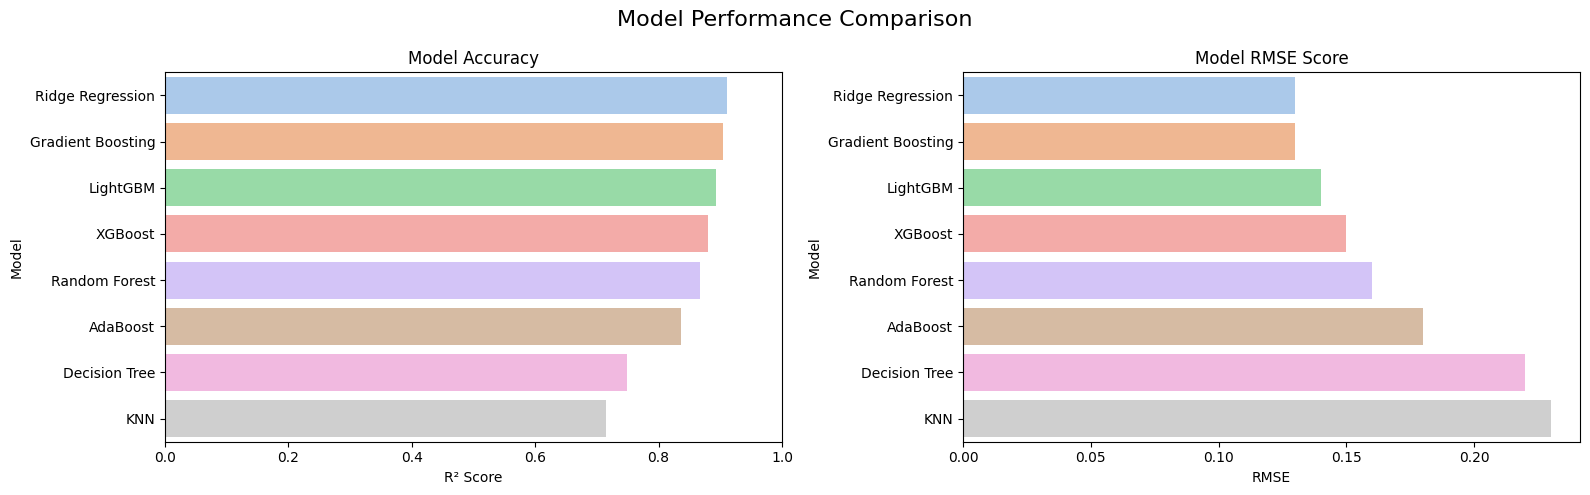

In [76]:
# Sort by F1 Score (or Accuracy if you want)
regression_df_sorted = regression_df.sort_values(by="R² Score", ascending=False)  # Ascending so best model is at top (barplot is horizontal)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy plot
sns.barplot(
    y='Model', x='R² Score',
    data=regression_df_sorted,
    order=regression_df_sorted['Model'],
    palette='pastel',
    ax=axes[0]
)
axes[0].set_title("Model Accuracy")
axes[0].set_xlim(0, 1)

# F1 Score plot
sns.barplot(
    y='Model', x='RMSE',
    data=regression_df_sorted,
    order=regression_df_sorted['Model'],
    palette='pastel',
    ax=axes[1]
)
axes[1].set_title("Model RMSE Score")

plt.suptitle("Model Performance Comparison", fontsize=16)
plt.tight_layout()
plt.show()

# **STEP 8: Model Evaluation**

In [77]:
models_grid = {
    'Ridge Regression': {
        'model': Ridge(random_state=42),
        'param_grid': {
            'alpha': [0.1, 1.0, 10.0]
        }
    },
    'KNN': {
        'model': KNeighborsRegressor(),
        'param_grid': {
            'n_neighbors': [3, 5, 7]
        }
    },
    'Decision Tree': {
        'model': DecisionTreeRegressor(random_state=42),
        'param_grid': {
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
        }
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'param_grid': {
            'n_estimators': [50, 100],
            'max_depth': [None, 10],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'param_grid': {
            'n_estimators': [50, 100],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 4],
        }
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42),
        'param_grid': {
            'n_estimators': [50, 100],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 4],
        }
    },
    'AdaBoost': {
        'model': AdaBoostRegressor(random_state=42),
        'param_grid': {
            'n_estimators': [50, 100],
            'learning_rate': [0.01, 0.1],
        }
    },
    'LightGBM': {
        'model': LGBMRegressor(random_state=42, verbose=-1),
        'param_grid': {
            'n_estimators': [50, 100],
            'learning_rate': [0.01, 0.1],
            'num_leaves': [31, 50],
        }
    }
}

# Train and evaluate models
summary_list = []
best_estimators = {}

for name, model_info in models_grid.items():
    print(f"🔍 Tuning: {name}")
    model = model_info['model']
    param_grid = model_info['param_grid']
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,
        scoring='r2',
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_val)
    
    mae = mean_absolute_error(y_val, y_pred)
    rmse = mean_squared_error(y_val, y_pred, squared=False)  # RMSE = sqrt(MSE)
    r2 = r2_score(y_val, y_pred)
    
    cross_val = cross_val_score(best_model, X_train,y_train,cv=5, scoring='r2')
    print(f"Mean cross-validation score: {cross_val.mean():.4f}")
    
    summary_list.append({
        "Model": name,
        "Best Params": grid_search.best_params_,
        "R² Score": round(r2, 4),
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "CV R²": round(cross_val.mean(), 4)
    })

    best_estimators[name] = best_model

# Create DataFrame and display
summary_df = pd.DataFrame(summary_list).sort_values(by="R² Score", ascending=False)
summary_df

🔍 Tuning: Ridge Regression
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Mean cross-validation score: 0.8622
🔍 Tuning: KNN
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Mean cross-validation score: 0.6597
🔍 Tuning: Decision Tree
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mean cross-validation score: 0.7427
🔍 Tuning: Random Forest
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mean cross-validation score: 0.8635
🔍 Tuning: Gradient Boosting
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mean cross-validation score: 0.8881
🔍 Tuning: XGBoost
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mean cross-validation score: 0.8880
🔍 Tuning: AdaBoost
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Mean cross-validation score: 0.8069
🔍 Tuning: LightGBM
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mean cross-validation score: 0.8862


,Model,Best Params,R² Score,MAE,RMSE,CV R²
4,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.9050,0.09,0.13,0.8881
5,XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.9042,0.09,0.13,0.8880
0,Ridge Regression,{'alpha': 10.0},0.8910,0.10,0.14,0.8622
7,LightGBM,"{'learning_rate': 0.1, 'n_estimators': 100, 'n...",0.8902,0.09,0.14,0.8862
3,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.8871,0.10,0.15,0.8635
6,AdaBoost,"{'learning_rate': 0.1, 'n_estimators': 100}",0.8271,0.12,0.18,0.8069
2,Decision Tree,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.8128,0.13,0.19,0.7427
1,KNN,{'n_neighbors': 7},0.7154,0.16,0.23,0.6597


In [81]:
# ✅ 1. Find the best model based on R² Score
best_model_name = summary_df.sort_values(by="R² Score", ascending=False).iloc[0]['Model']
best_model = best_estimators[best_model_name]

# ✅ 2. Predict on validation set
y_pred = best_model.predict(X_val)

# ✅ 3. Print performance summary
print(f"📊 Performance of Best Model: {best_model_name}")
print("R² Score:", round(r2_score(y_val, y_pred), 4))
print("MAE:", round(mean_absolute_error(y_val, y_pred), 2))
print("RMSE:", round(mean_squared_error(y_val, y_pred) ** 0.5, 2))


📊 Performance of Best Model: Gradient Boosting
R² Score: 0.905
MAE: 0.09
RMSE: 0.13


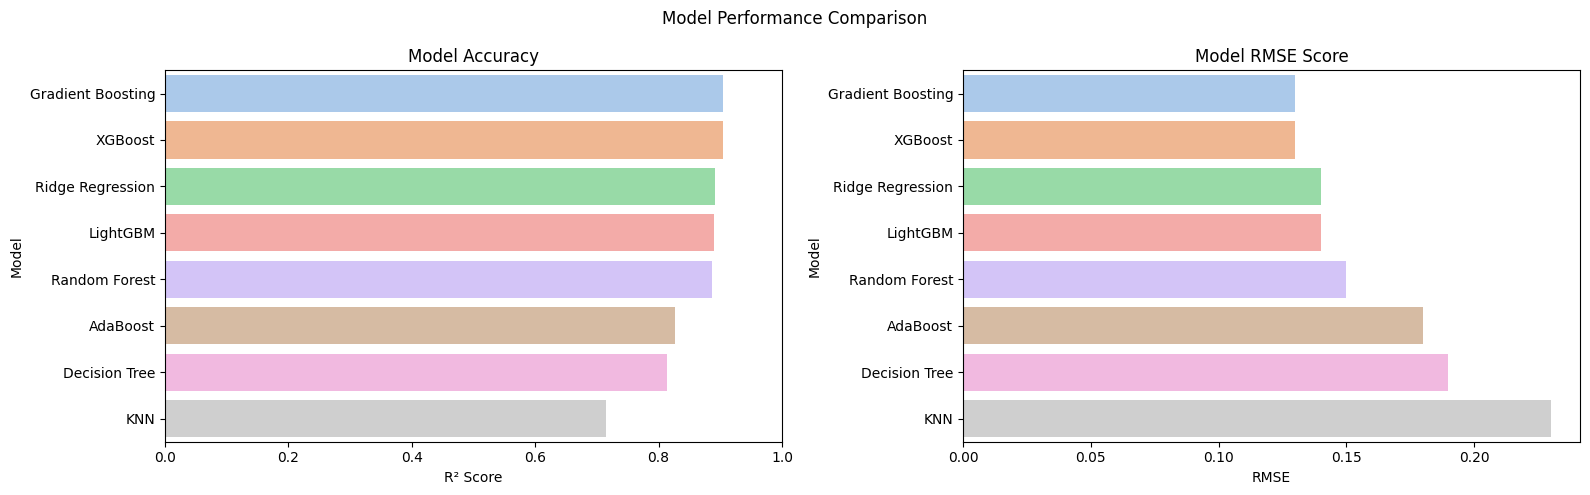

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(y=summary_df['Model'], x=summary_df['R² Score'], palette='pastel', ax=axes[0])
axes[0].set_title("Model Accuracy")
axes[0].set_xlim(0, 1)

sns.barplot(y=summary_df['Model'], x=summary_df['RMSE'], palette='pastel', ax=axes[1])
axes[1].set_title("Model RMSE Score")

plt.suptitle("Model Performance Comparison")
plt.tight_layout()
plt.show()

# **Step 9: Deployment & Submission**

In [89]:
# combine train and validation sets
X_full = pd.concat([X_train,X_val])
y_full = pd.concat([y_train, y_val])

# refit scaler on full data
final_scaler = MinMaxScaler()
X_full_scaled = final_scaler.fit_transform(X_full)
X_test_scaled = final_scaler.transform(X_test_selected)

# Load best tuned model
sorted_best_tuned_model = summary_df.sort_values(by='R² Score',ascending=False)
best_model_name = sorted_best_tuned_model.iloc[0]['Model']
best_model = best_estimators[best_model_name]

# Retrain best model on full data
# final_model = best_model.__class__(**best_model.get_params())  # copy tuned parameters
# final_model = best_model.fit(X_full_scaled, y_full)

# # Predict on test set (log values)
# test_predictions_log = final_model.predict(X_test_scaled)
# test_predictions = np.expm1(test_predictions_log)  # convert back from log scale

# Retrain Ridge on full data
ridge_model = best_estimators["Ridge Regression"]
ridge_final = ridge_model.__class__(**ridge_model.get_params())
ridge_final.fit(X_full_scaled, y_full)

# Retrain XGBoost on full data
xgb_model = best_estimators["XGBoost"]
xgb_final = xgb_model.__class__(**xgb_model.get_params())
xgb_final.fit(X_full_scaled, y_full)

# Predict on test set (log scale)
ridge_preds_log = ridge_final.predict(X_test_scaled)
xgb_preds_log = xgb_final.predict(X_test_scaled)

# Blend predictions (log space)
blended_preds_log = (ridge_preds_log + xgb_preds_log) / 2

# Convert back from log to original scale
final_preds = np.expm1(blended_preds_log)

# Prepare submission file
submission = pd.read_csv("C:/Users/ARZ/Desktop/sample_submission.csv")
submission["SalePrice"] = final_preds # Reverse the log1p
submission.to_csv("submission.csv", index=False)

# Save final model and scaler
joblib.dump(final_preds, "final_model.pkl")
joblib.dump(final_scaler, "final_scaler.pkl")

print(f"✅ Submission file saved as submission.csv")
print(f"✅ Final model saved as final_model.pkl")
print(f"✅ Final scaler saved as final_scaler.pkl")

✅ Submission file saved as submission.csv
✅ Final model saved as final_model.pkl
✅ Final scaler saved as final_scaler.pkl
